In [24]:
#Cell 0

import pandas as pd
import numpy as np
from astroquery.gaia import Gaia
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [25]:
# Dummy Cell: Precreates gaia_data_results.csv to allow the entire code to be run without interruption, when Cell 1 fails to fetch data from Gaia. 
# This ensures that downstream cells can execute without being blocked by missing files.
import pandas as pd
import os

# Force-create a dummy TOI CSV with a 'tid' column so Cell 1 loops over nothing
pd.DataFrame({'tid': []}).to_csv('TOI_2024.08.03_15.56.31.csv', index=False)
print("Created placeholder TOI CSV")

# Create a placeholder gaia_data_results.csv for downstream cells
if not os.path.exists('gaia_data_results.csv'):
    cols = [
        'SOURCE_ID', 'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'phot_bp_mean_mag',
        'phot_rp_mean_mag', 'radial_velocity', 'astrometric_excess_noise',
        'astrometric_excess_noise_sig', 'ra', 'ra_error', 'dec', 'dec_error',
        'parallax_error', 'parallax_over_error', 'pmra_error', 'pmdec_error',
        'astrometric_n_obs_al', 'astrometric_n_obs_ac', 'astrometric_n_good_obs_al',
        'astrometric_n_bad_obs_al', 'astrometric_gof_al', 'astrometric_chi2_al',
        'nu_eff_used_in_astrometry', 'astrometric_matched_transits',
        'visibility_periods_used', 'astrometric_sigma5d_max', 'ruwe',
        'phot_g_mean_flux', 'phot_g_mean_flux_error', 'phot_g_mean_flux_over_error',
        'phot_bp_mean_flux', 'phot_bp_mean_flux_error', 'phot_bp_mean_flux_over_error',
        'phot_rp_mean_flux', 'phot_rp_mean_flux_error', 'phot_rp_mean_flux_over_error',
        'radial_velocity_error', 'rv_method_used', 'rv_nb_transits',
        'rv_nb_deblended_transits', 'rv_visibility_periods_used',
        'rv_expected_sig_to_noise', 'rv_renormalised_gof', 'rv_chisq_pvalue',
        'rv_time_duration', 'rv_amplitude_robust', 'rv_template_teff',
        'rv_template_logg', 'rv_template_fe_h', 'vbroad', 'vbroad_error',
        'vbroad_nb_transits', 'grvs_mag', 'grvs_mag_error', 'grvs_mag_nb_transits',
        'rvs_spec_sig_to_noise'
    ]
    pd.DataFrame(columns=cols).to_csv('gaia_data_results.csv', index=False)
    print("Created placeholder gaia_data_results.csv")
else:
    print("gaia_data_results.csv already exists, skipping.")

Created placeholder TOI CSV
gaia_data_results.csv already exists, skipping.


In [26]:
#Cell 1

# For getting Gaia Data from NASA Archive through TIC #
# DONT RUN UNLESS YOU NEED THE DATA

import pandas as pd
from astroquery.simbad import Simbad
from astroquery.gaia import Gaia
from astropy.table import Table

def get_gaia_source_id(tic_id):
    try:
        custom_simbad = Simbad()
        custom_simbad.add_votable_fields('ids')
        result = custom_simbad.query_object(f"TIC {tic_id}")
        if result is not None:
            ids = result['IDS'][0]
            for id in ids.split('|'):
                if 'Gaia DR3' in id:
                    return id.split(' ')[-1]
                elif 'Gaia DR2' in id:
                    return id.split(' ')[-1]
                elif 'Gaia DR1' in id:
                    return id.split(' ')[-1]
    except Exception as e:
        print(f"Warning: {e} for TIC {tic_id}")
    return None

def query_gaia_data(source_id):
    query = f"""
    SELECT source_id AS SOURCE_ID, parallax, pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, radial_velocity, 
    astrometric_excess_noise, astrometric_excess_noise_sig, ra, ra_error, dec, dec_error, parallax_error, 
    parallax_over_error, pmra_error, pmdec_error, astrometric_n_obs_al, astrometric_n_obs_ac, 
    astrometric_n_good_obs_al, astrometric_n_bad_obs_al, astrometric_gof_al, astrometric_chi2_al, 
    nu_eff_used_in_astrometry, astrometric_matched_transits, visibility_periods_used, 
    astrometric_sigma5d_max, ruwe, phot_g_mean_flux, phot_g_mean_flux_error, phot_g_mean_flux_over_error, 
    phot_bp_mean_flux, phot_bp_mean_flux_error, phot_bp_mean_flux_over_error, phot_rp_mean_flux, 
    phot_rp_mean_flux_error, phot_rp_mean_flux_over_error, radial_velocity_error, rv_method_used, 
    rv_nb_transits, rv_nb_deblended_transits, rv_visibility_periods_used, rv_expected_sig_to_noise, 
    rv_renormalised_gof, rv_chisq_pvalue, rv_time_duration, rv_amplitude_robust, rv_template_teff, 
    rv_template_logg, rv_template_fe_h, vbroad, vbroad_error, vbroad_nb_transits, grvs_mag, 
    grvs_mag_error, grvs_mag_nb_transits, rvs_spec_sig_to_noise
    FROM gaiadr3.gaia_source
    WHERE source_id = {source_id}
    """
    job = Gaia.launch_job(query)
    results = job.get_results()
    return results


csv_file = 'TOI_2024.08.03_15.56.31.csv'
df = pd.read_csv(csv_file)

gaia_data = []

for tic_id in df['tid']:
    gaia_source_id = get_gaia_source_id(tic_id)
    if gaia_source_id:
        gaia_data.append(query_gaia_data(gaia_source_id))

if gaia_data:
    gaia_df = pd.concat([table.to_pandas() for table in gaia_data], ignore_index=True)
    output_csv = 'gaia_data_results.csv'
    gaia_df.to_csv(output_csv, index=False)
    print(f"GAIA data has been saved to {output_csv}")
else:
    print("No GAIA data found.")

No GAIA data found.


In [27]:
import pandas as pd
df = pd.read_csv('PS_2024.07.13_00.00.28.csv', on_bad_lines='skip', comment='#')

gaia_cols = [col for col in df.columns if 'gaia' in col.lower()]\

print(gaia_cols)

print(df['hostname'].head(20))
print(f"\nTotal confirmed planets: {len(df)}")
print(f"Unique host stars: {df['hostname'].nunique()}")

['sy_gaiamag', 'sy_gaiamagerr1', 'sy_gaiamagerr2']
0       11 Com
1       11 Com
2       11 Com
3       11 UMi
4       11 UMi
5       11 UMi
6       14 And
7       14 And
8       14 And
9       14 Her
10      14 Her
11      14 Her
12      14 Her
13      14 Her
14      14 Her
15      14 Her
16      14 Her
17    16 Cyg B
18    16 Cyg B
19    16 Cyg B
Name: hostname, dtype: str

Total confirmed planets: 39443
Unique host stars: 4566


In [28]:
# Cell 2 — Confirmed Planets Gaia Query (fixed)

import pandas as pd
from astroquery.simbad import Simbad
from astroquery.gaia import Gaia
import time

# Load the NASA Exoplanet Archive CSV
file_path = 'PS_2024.07.13_00.00.28.csv'
nasa_exoplanets_data = pd.read_csv(file_path, on_bad_lines='skip', comment='#')

# Get unique host star names only
host_stars = nasa_exoplanets_data['hostname'].dropna().unique().tolist()
print(f"Unique host stars to resolve: {len(host_stars)}")

# Set up SIMBAD to return all IDs
custom_simbad = Simbad()
custom_simbad.add_votable_fields('ids')

# Resolve each host star name to a Gaia DR3 source ID
gaia_source_ids = []
failed = []

for i, star in enumerate(host_stars):
    try:
        result = custom_simbad.query_object(star)
        if result is not None:
            ids = result['ids'][0]  # lowercase 'ids'
            gaia_id = None
            for id_entry in ids.split('|'):
                if 'Gaia DR3' in id_entry:
                    gaia_id = id_entry.split(' ')[-1]
                    break
                elif 'Gaia DR2' in id_entry and gaia_id is None:
                    gaia_id = id_entry.split(' ')[-1]  # fallback
            if gaia_id:
                gaia_source_ids.append(gaia_id)
            else:
                failed.append(star)
        else:
            failed.append(star)
    except Exception as e:
        failed.append(star)

    # Progress update every 100 stars
    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{len(host_stars)} — resolved so far: {len(gaia_source_ids)}")

    # Small delay to avoid hammering SIMBAD
    time.sleep(0.1)

print(f"\nResolved: {len(gaia_source_ids)} stars")
print(f"Failed:   {len(failed)} stars")

# Query Gaia DR3 in batches of 500 to avoid HTTP errors
all_results = []
batch_size = 500

for i in range(0, len(gaia_source_ids), batch_size):
    batch = gaia_source_ids[i:i + batch_size]
    ids_str = ', '.join(batch)
    query = f"""
    SELECT source_id AS SOURCE_ID, parallax, pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, radial_velocity, 
    astrometric_excess_noise, astrometric_excess_noise_sig, ra, ra_error, dec, dec_error, parallax_error, 
    parallax_over_error, pmra_error, pmdec_error, astrometric_n_obs_al, astrometric_n_obs_ac, 
    astrometric_n_good_obs_al, astrometric_n_bad_obs_al, astrometric_gof_al, astrometric_chi2_al, 
    nu_eff_used_in_astrometry, astrometric_matched_transits, visibility_periods_used, 
    astrometric_sigma5d_max, ruwe, phot_g_mean_flux, phot_g_mean_flux_error, phot_g_mean_flux_over_error, 
    phot_bp_mean_flux, phot_bp_mean_flux_error, phot_bp_mean_flux_over_error, phot_rp_mean_flux, 
    phot_rp_mean_flux_error, phot_rp_mean_flux_over_error, radial_velocity_error, rv_method_used, 
    rv_nb_transits, rv_nb_deblended_transits, rv_visibility_periods_used, rv_expected_sig_to_noise, 
    rv_renormalised_gof, rv_chisq_pvalue, rv_time_duration, rv_amplitude_robust, rv_template_teff, 
    rv_template_logg, rv_template_fe_h, vbroad, vbroad_error, vbroad_nb_transits, grvs_mag, 
    grvs_mag_error, grvs_mag_nb_transits, rvs_spec_sig_to_noise
    FROM gaiadr3.gaia_source
    WHERE source_id IN ({ids_str})
    """
    try:
        job = Gaia.launch_job_async(query)
        result = job.get_results()
        all_results.append(result.to_pandas())
        print(f"Batch {i//batch_size + 1}: retrieved {len(result)} rows")
    except Exception as e:
        print(f"Batch {i//batch_size + 1} failed: {e}")

# Combine all batches and save
import pandas as pd
final_df = pd.concat(all_results, ignore_index=True)
print(f"\nTotal rows retrieved: {len(final_df)}")
final_df.to_csv('gaia_query_results.csv', index=False)
print("Saved to gaia_query_results.csv")

Unique host stars to resolve: 4566


  Processed 100/4566 — resolved so far: 91
  Processed 200/4566 — resolved so far: 188
  Processed 300/4566 — resolved so far: 286
  Processed 400/4566 — resolved so far: 384
  Processed 500/4566 — resolved so far: 484
  Processed 600/4566 — resolved so far: 582
  Processed 700/4566 — resolved so far: 682
  Processed 800/4566 — resolved so far: 781
  Processed 900/4566 — resolved so far: 877
  Processed 1000/4566 — resolved so far: 977
  Processed 1100/4566 — resolved so far: 1073
  Processed 1200/4566 — resolved so far: 1172
  Processed 1300/4566 — resolved so far: 1263
  Processed 1400/4566 — resolved so far: 1362
  Processed 1500/4566 — resolved so far: 1396
  Processed 1600/4566 — resolved so far: 1438
  Processed 1700/4566 — resolved so far: 1534
  Processed 1800/4566 — resolved so far: 1634
  Processed 1900/4566 — resolved so far: 1733
  Processed 2000/4566 — resolved so far: 1832
  Processed 2100/4566 — resolved so far: 1929
  Processed 2200/4566 — resolved so far: 2026
  Proces

In [29]:
# In Between Cell - Double confirmation targets have beenn saved to Gaia Query Results

print(f"Resolved: {len(gaia_source_ids)}")
print(f"Failed:   {len(failed)}")
if len(gaia_source_ids) > 0:
    print("Sample IDs:", gaia_source_ids[:5])

import os
print(os.path.exists('gaia_query_results.csv'))
import pandas as pd
df_check = pd.read_csv('gaia_query_results.csv')
print(f"Rows in gaia_query_results.csv: {len(df_check)}")
print(df_check.columns.tolist())

Resolved: 4156
Failed:   410
Sample IDs: ['3946945413106333696', '1696798367260229376', '1920113512486282240', '1385293808145621504', '2135550755683407232']
True
Rows in gaia_query_results.csv: 4154
['SOURCE_ID', 'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'radial_velocity', 'astrometric_excess_noise', 'astrometric_excess_noise_sig', 'ra', 'ra_error', 'dec', 'dec_error', 'parallax_error', 'parallax_over_error', 'pmra_error', 'pmdec_error', 'astrometric_n_obs_al', 'astrometric_n_obs_ac', 'astrometric_n_good_obs_al', 'astrometric_n_bad_obs_al', 'astrometric_gof_al', 'astrometric_chi2_al', 'nu_eff_used_in_astrometry', 'astrometric_matched_transits', 'visibility_periods_used', 'astrometric_sigma5d_max', 'ruwe', 'phot_g_mean_flux', 'phot_g_mean_flux_error', 'phot_g_mean_flux_over_error', 'phot_bp_mean_flux', 'phot_bp_mean_flux_error', 'phot_bp_mean_flux_over_error', 'phot_rp_mean_flux', 'phot_rp_mean_flux_error', 'phot_rp_mean_flux_over_error', 'r

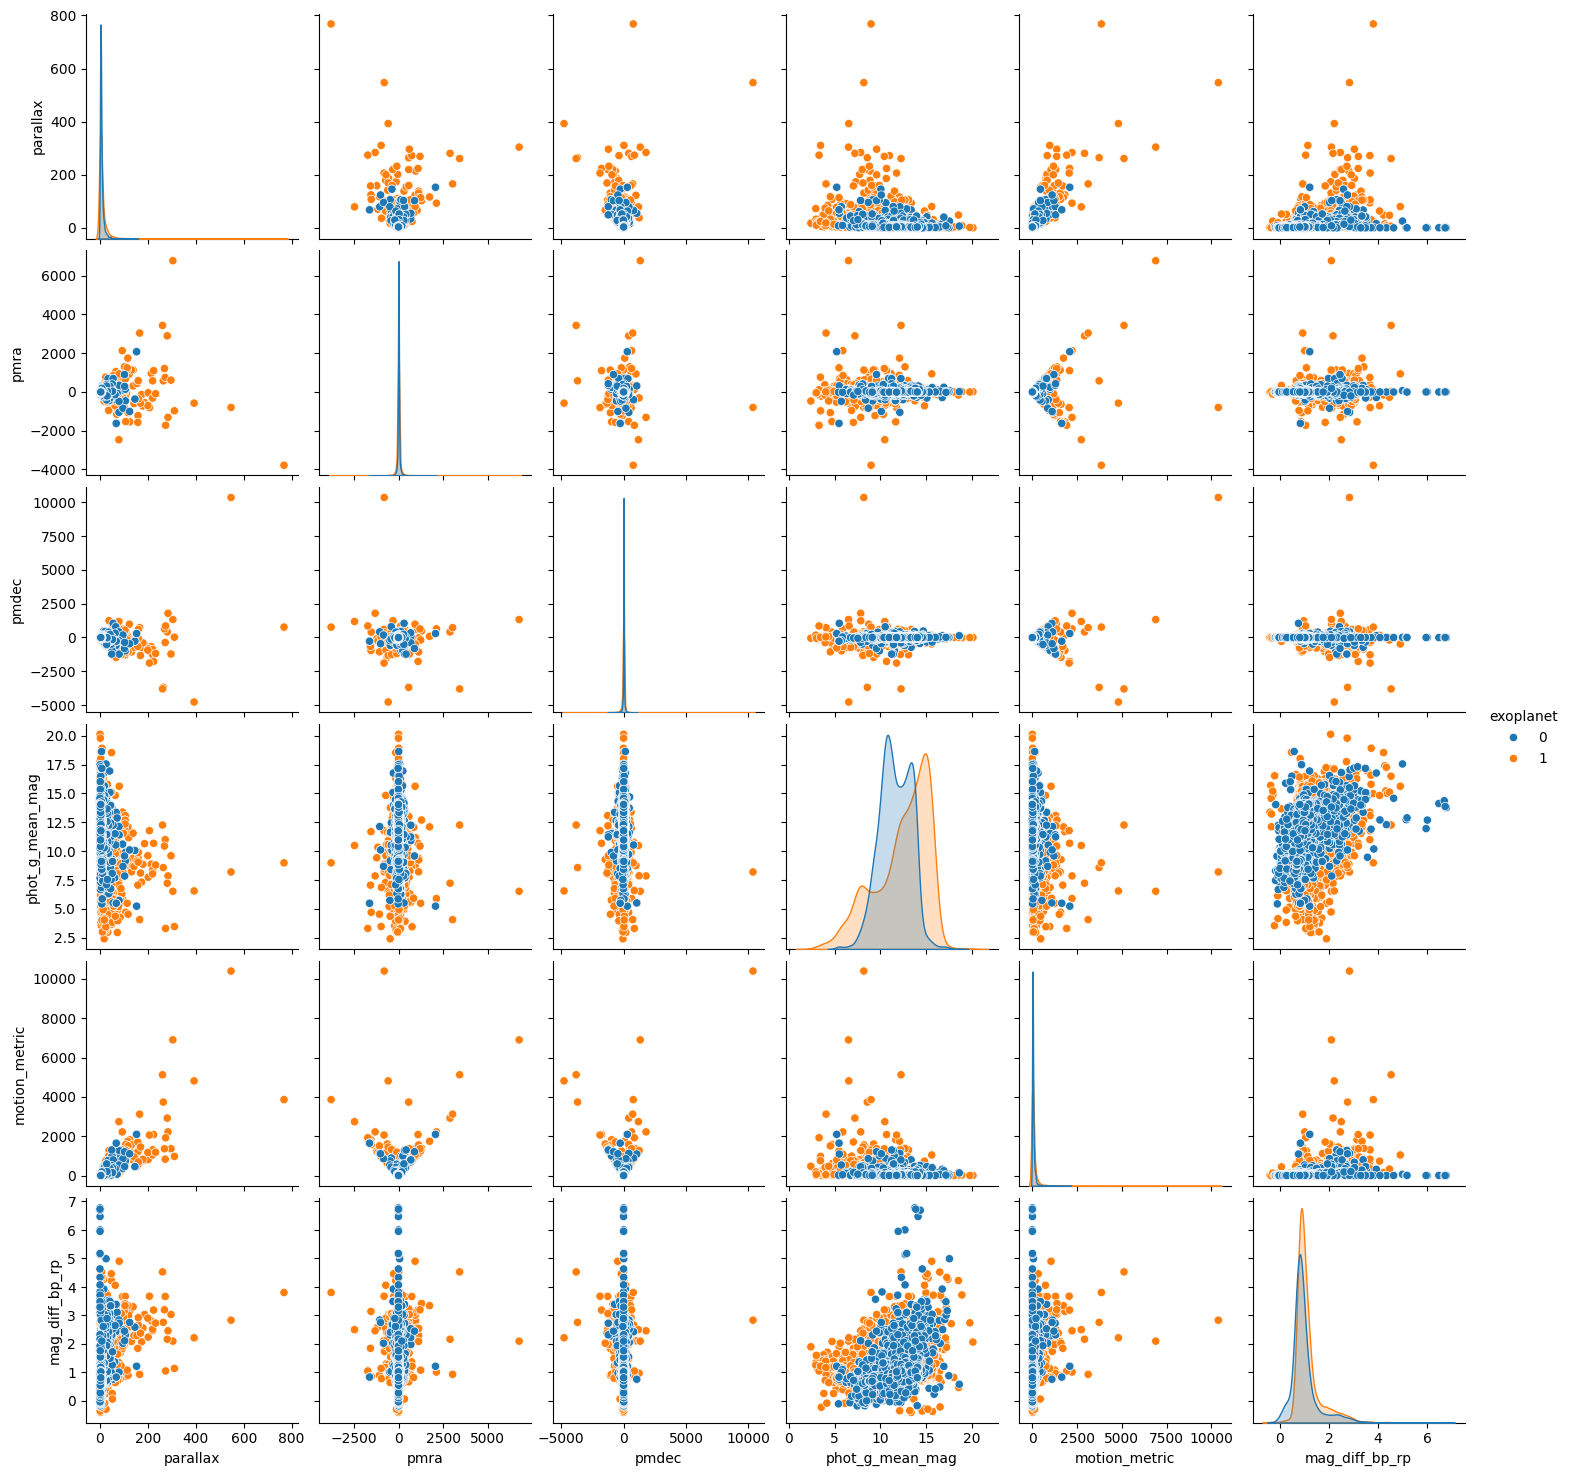

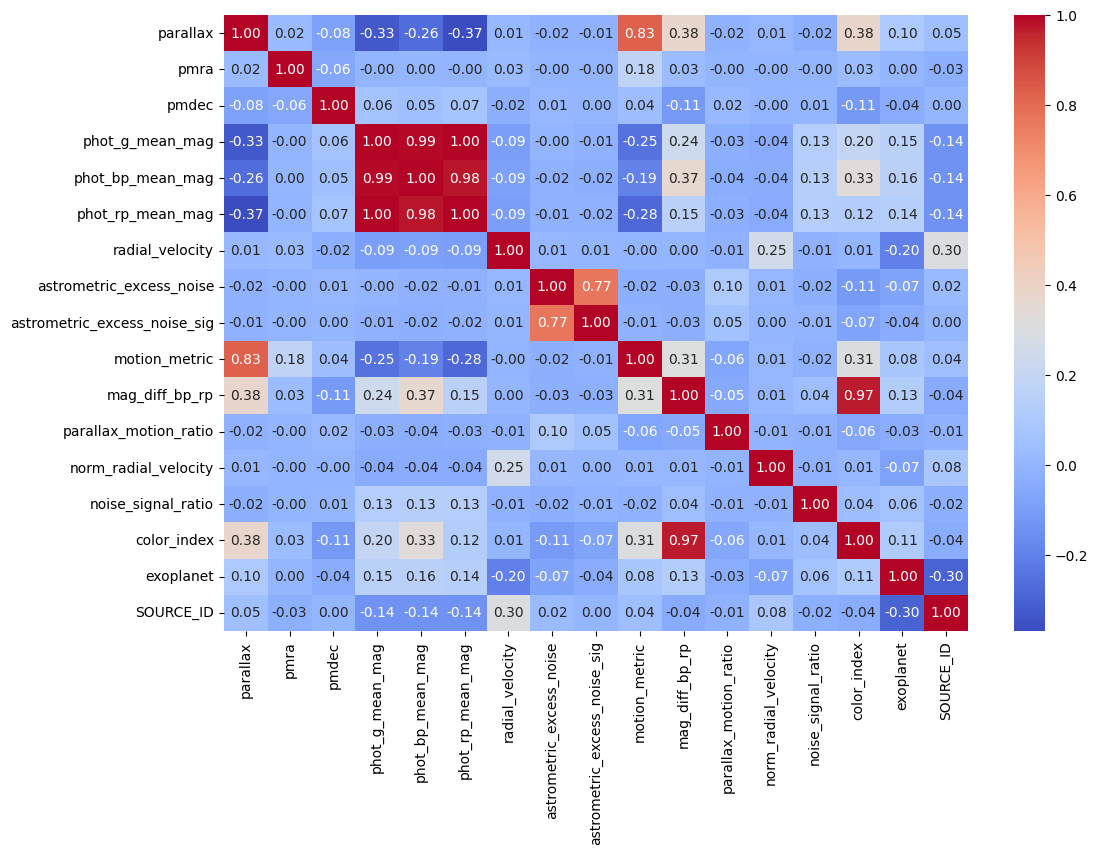

Target distribution before SMOTE: exoplanet
1    3295
0    2937
Name: count, dtype: int64
Target distribution after SMOTE: (array([0, 1]), array([3295, 3295]))
Shape of X_train_balanced: (6590, 15)
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Cross-validated ROC AUC scores: [0.84644044 0.84445555 0.84498286 0.85122766 0.85043785]
Mean ROC AUC score: 0.8475088709844547
              precision    recall  f1-score   support

           0       0.68      0.85      0.75       699
           1       0.84      0.67      0.75       859

    accuracy                           0.75      1558
   macro avg       0.76      0.76      0.75      1558
weighted avg       0.77      0.75      0.75      1558

ROC AUC Score on test set: 0.8533661092430398
Feature importances:
 phot_rp_mean_mag                0.222841
phot_g_mean_mag                 0.172424
phot_bp_mean_mag                0.132605
radial_velocity                 0.077259
norm_radial_velocity            0.074785
astrometric_e

In [30]:
#Cell 3

# Machine Learning Model Using False Positives

import pandas as pd
import numpy as np
import joblib
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocess GAIA data — imputation only, scaling happens after the split
def preprocess_data(df):
    SOURCE_IDs = df['SOURCE_ID']
    df = df.drop('SOURCE_ID', axis=1)
    imputer = SimpleImputer(strategy='median')
    df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
    df_imputed['SOURCE_ID'] = SOURCE_IDs.values
    return df_imputed

confirmed_planets_data = pd.read_csv('gaia_query_results.csv')
confirmed_data = preprocess_data(confirmed_planets_data)
confirmed_data['exoplanet'] = 1

false_positives_data = pd.read_csv('gaia_data_results.csv')
false_positives_data = preprocess_data(false_positives_data)
false_positives_data['exoplanet'] = 0
combined_data = pd.concat([confirmed_data, false_positives_data], ignore_index=True)

# Feature engineering
def feature_engineering(df):
    df['motion_metric'] = np.sqrt(df['pmra']**2 + df['pmdec']**2)
    df['mag_diff_bp_rp'] = df['phot_bp_mean_mag'] - df['phot_rp_mean_mag']
    df['parallax_motion_ratio'] = df['parallax'] / df['motion_metric'].replace(0, np.nan)
    df['norm_radial_velocity'] = df['radial_velocity'] / df['parallax'].replace(0, np.nan)
    df['noise_signal_ratio'] = df['astrometric_excess_noise'] / df['astrometric_excess_noise_sig'].replace(0, np.nan)
    df['color_index'] = df['phot_bp_mean_mag'] - df['phot_g_mean_mag']
    return df

combined_data = feature_engineering(combined_data)

# Clean up any NaN or Inf values produced by feature engineering
combined_data = combined_data.replace([np.inf, -np.inf], np.nan)
source_ids_backup = combined_data['SOURCE_ID']
labels_backup = combined_data['exoplanet']
model_columns = [
    'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'radial_velocity',
    'astrometric_excess_noise', 'astrometric_excess_noise_sig', 'motion_metric', 'mag_diff_bp_rp',
    'parallax_motion_ratio', 'norm_radial_velocity', 'noise_signal_ratio', 'color_index'
]
imputer_features = SimpleImputer(strategy='median')
combined_data[model_columns] = imputer_features.fit_transform(combined_data[model_columns])
combined_data['SOURCE_ID'] = source_ids_backup.values
combined_data['exoplanet'] = labels_backup.values
combined_data = combined_data[model_columns + ['exoplanet', 'SOURCE_ID']]

# EDA
def perform_eda(df):
    sns.pairplot(df[['parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'motion_metric', 'mag_diff_bp_rp', 'exoplanet']], hue='exoplanet')
    plt.show()
    corr_matrix = df.corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.show()

perform_eda(combined_data)

X = combined_data.drop(['exoplanet', 'SOURCE_ID'], axis=1)
y = combined_data['exoplanet']

# STEP 1: Split first, before any scaling or SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 2: Fit scaler on training data only, then apply to both sets
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

# Final NaN cleanup after scaling
imputer_final = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer_final.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer_final.transform(X_test),      columns=X_test.columns)

# Save scaler for reuse in later cells
joblib.dump(scaler, 'training_scaler.pkl')

# STEP 3: Apply SMOTE to training data only
print("Target distribution before SMOTE:", y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print("Target distribution after SMOTE:", np.unique(y_train_balanced, return_counts=True))
print("Shape of X_train_balanced:", X_train_balanced.shape)

# Hyperparameter tuning
param_grid = {
    'n_estimators': [5000, 6000],
    'max_depth': [5, 10],
    'min_samples_split': [10, 15],
    'min_samples_leaf': [80, 100]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_balanced, y_train_balanced)

cv_scores = cross_val_score(grid_search.best_estimator_, X_train_balanced, y_train_balanced, cv=5, scoring='roc_auc')
print("Cross-validated ROC AUC scores:", cv_scores)
print("Mean ROC AUC score:", np.mean(cv_scores))

# STEP 4: Evaluate on the original, untouched test set
best_model = grid_search.best_estimator_
joblib.dump(best_model, 'best_model.pkl')
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]  # FIX: define before use

print(classification_report(y_test, y_pred))
print("ROC AUC Score on test set:", roc_auc_score(y_test, y_pred_proba))

feature_importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
print("Feature importances:\n", feature_importances.sort_values(ascending=False))

X_full = combined_data[model_columns]
combined_data['probability'] = best_model.predict_proba(X_full)[:, 1]

# Show top confirmed planet hosts by score — for model validation only
top_candidates = combined_data[combined_data['exoplanet'] == 1].nlargest(10, 'probability')

print("Top 10 Highest-Scoring Confirmed Exoplanet Hosts (validation check):")
print(top_candidates[['SOURCE_ID', 'probability']])

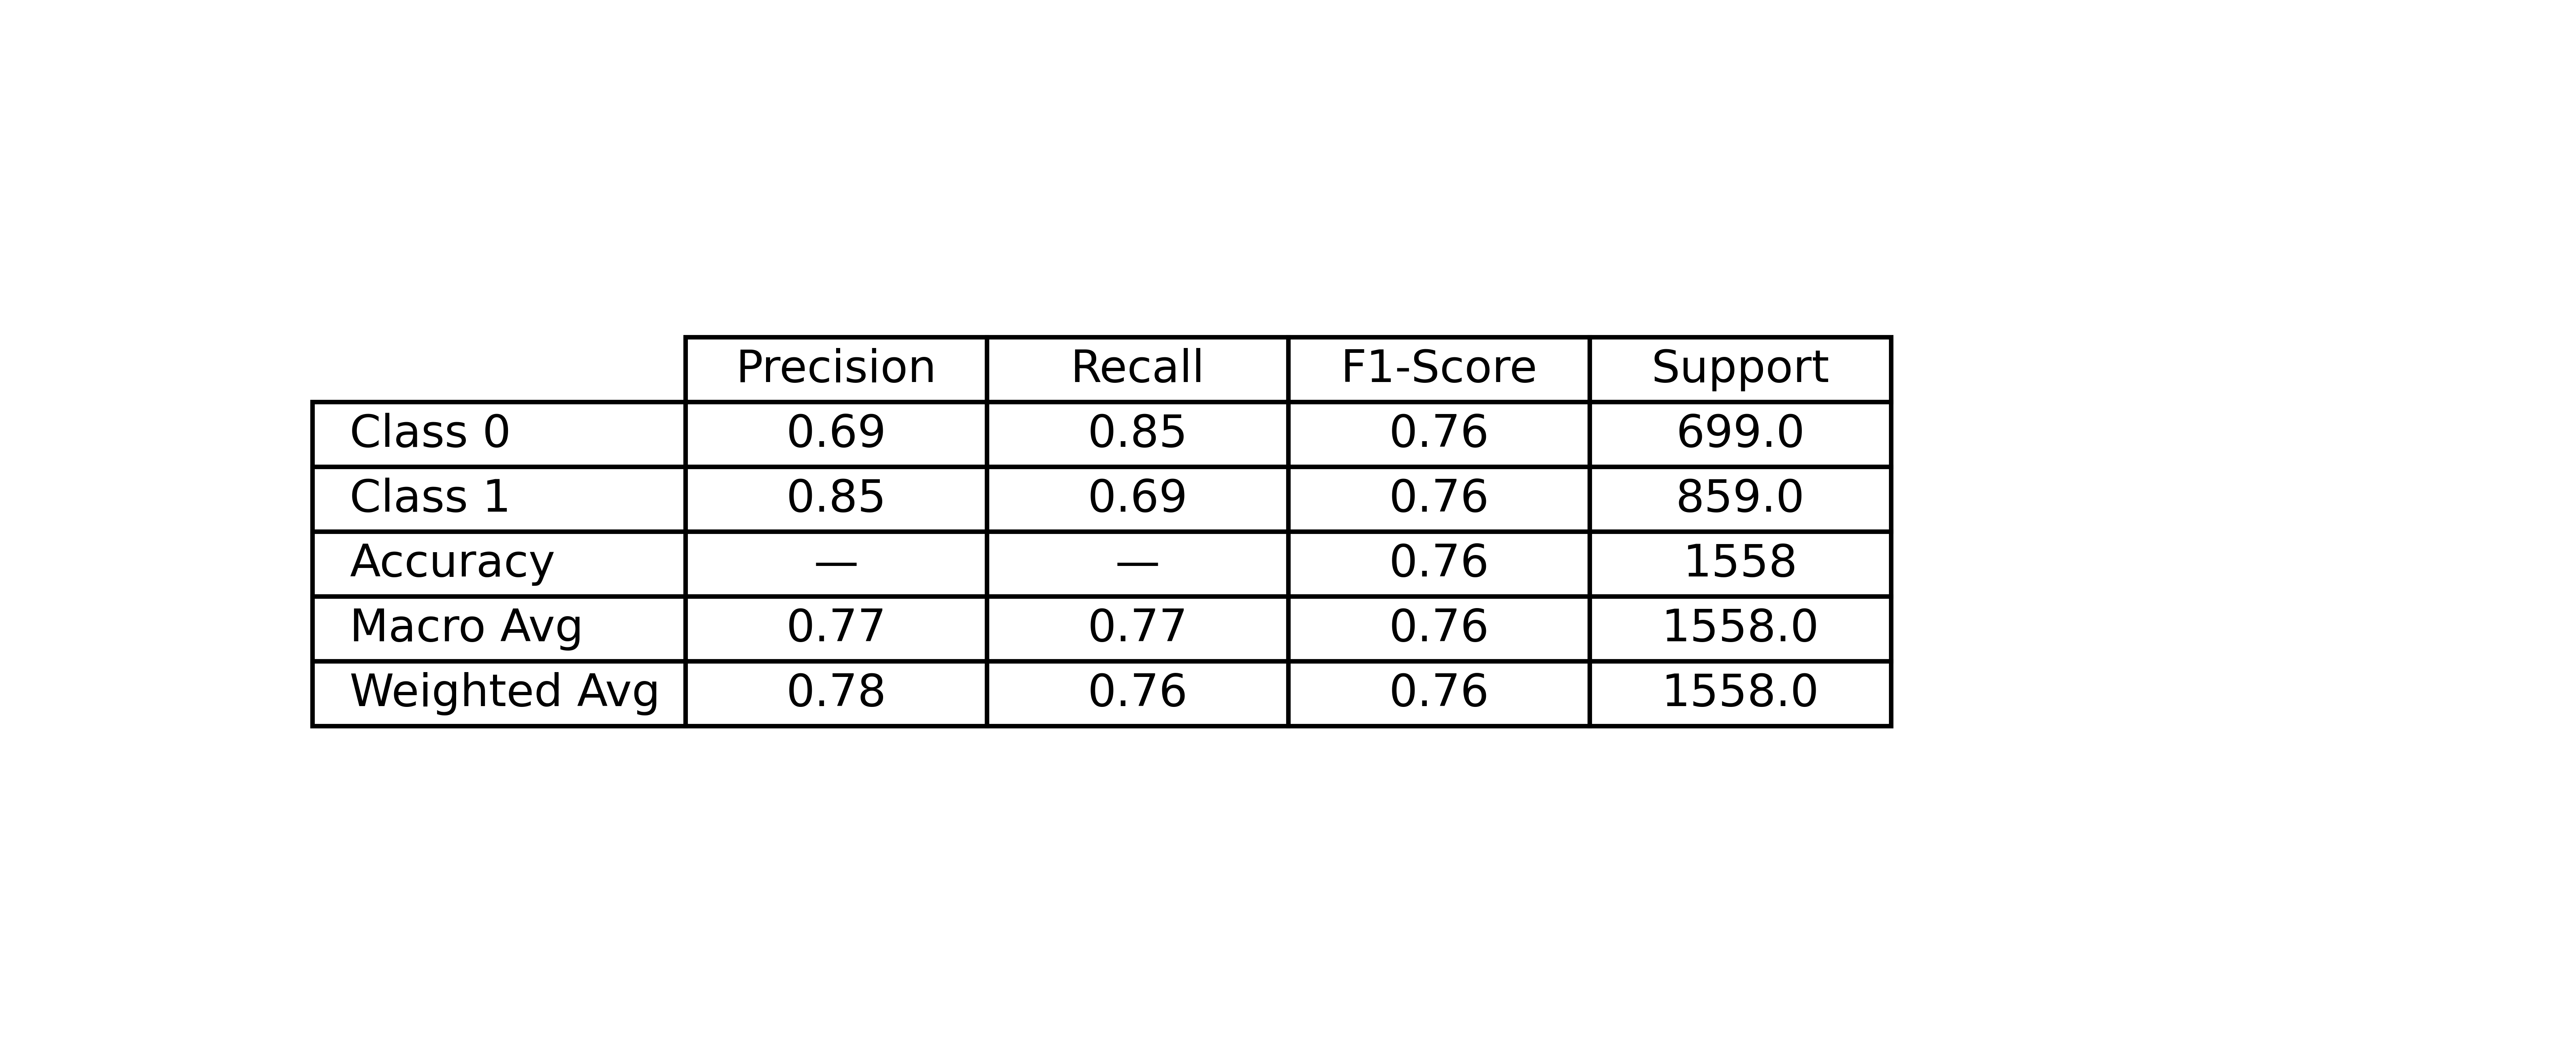

In [31]:
#cell 4

import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table

# Define the data from the classification report
data = {
    'Class 0': {'Precision': 0.69, 'Recall': 0.85, 'F1-Score': 0.76, 'Support': 699},
    'Class 1': {'Precision': 0.85, 'Recall': 0.69, 'F1-Score': 0.76, 'Support': 859},
    'Accuracy': {'Precision': '—', 'Recall': '—', 'F1-Score': 0.76, 'Support': 1558},
    'Macro Avg': {'Precision': 0.77, 'Recall': 0.77, 'F1-Score': 0.76, 'Support': 1558},
    'Weighted Avg': {'Precision': 0.78, 'Recall': 0.76, 'F1-Score': 0.76, 'Support': 1558}
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame(data)

# Ensure 'Support' is displayed as an integer
df.loc['Support'] = df.loc['Support'].astype(int)

# Transpose the DataFrame for better readability
df = df.T

# Plot the table
fig, ax = plt.subplots(figsize=(10, 4), dpi=800)  # Set the figure size
ax.axis('off')  # Hide the axis
tbl = table(ax, df, loc='center', cellLoc='center', colWidths=[0.1]*len(df.columns))  # Create the table

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)  # Scale the table

plt.show()

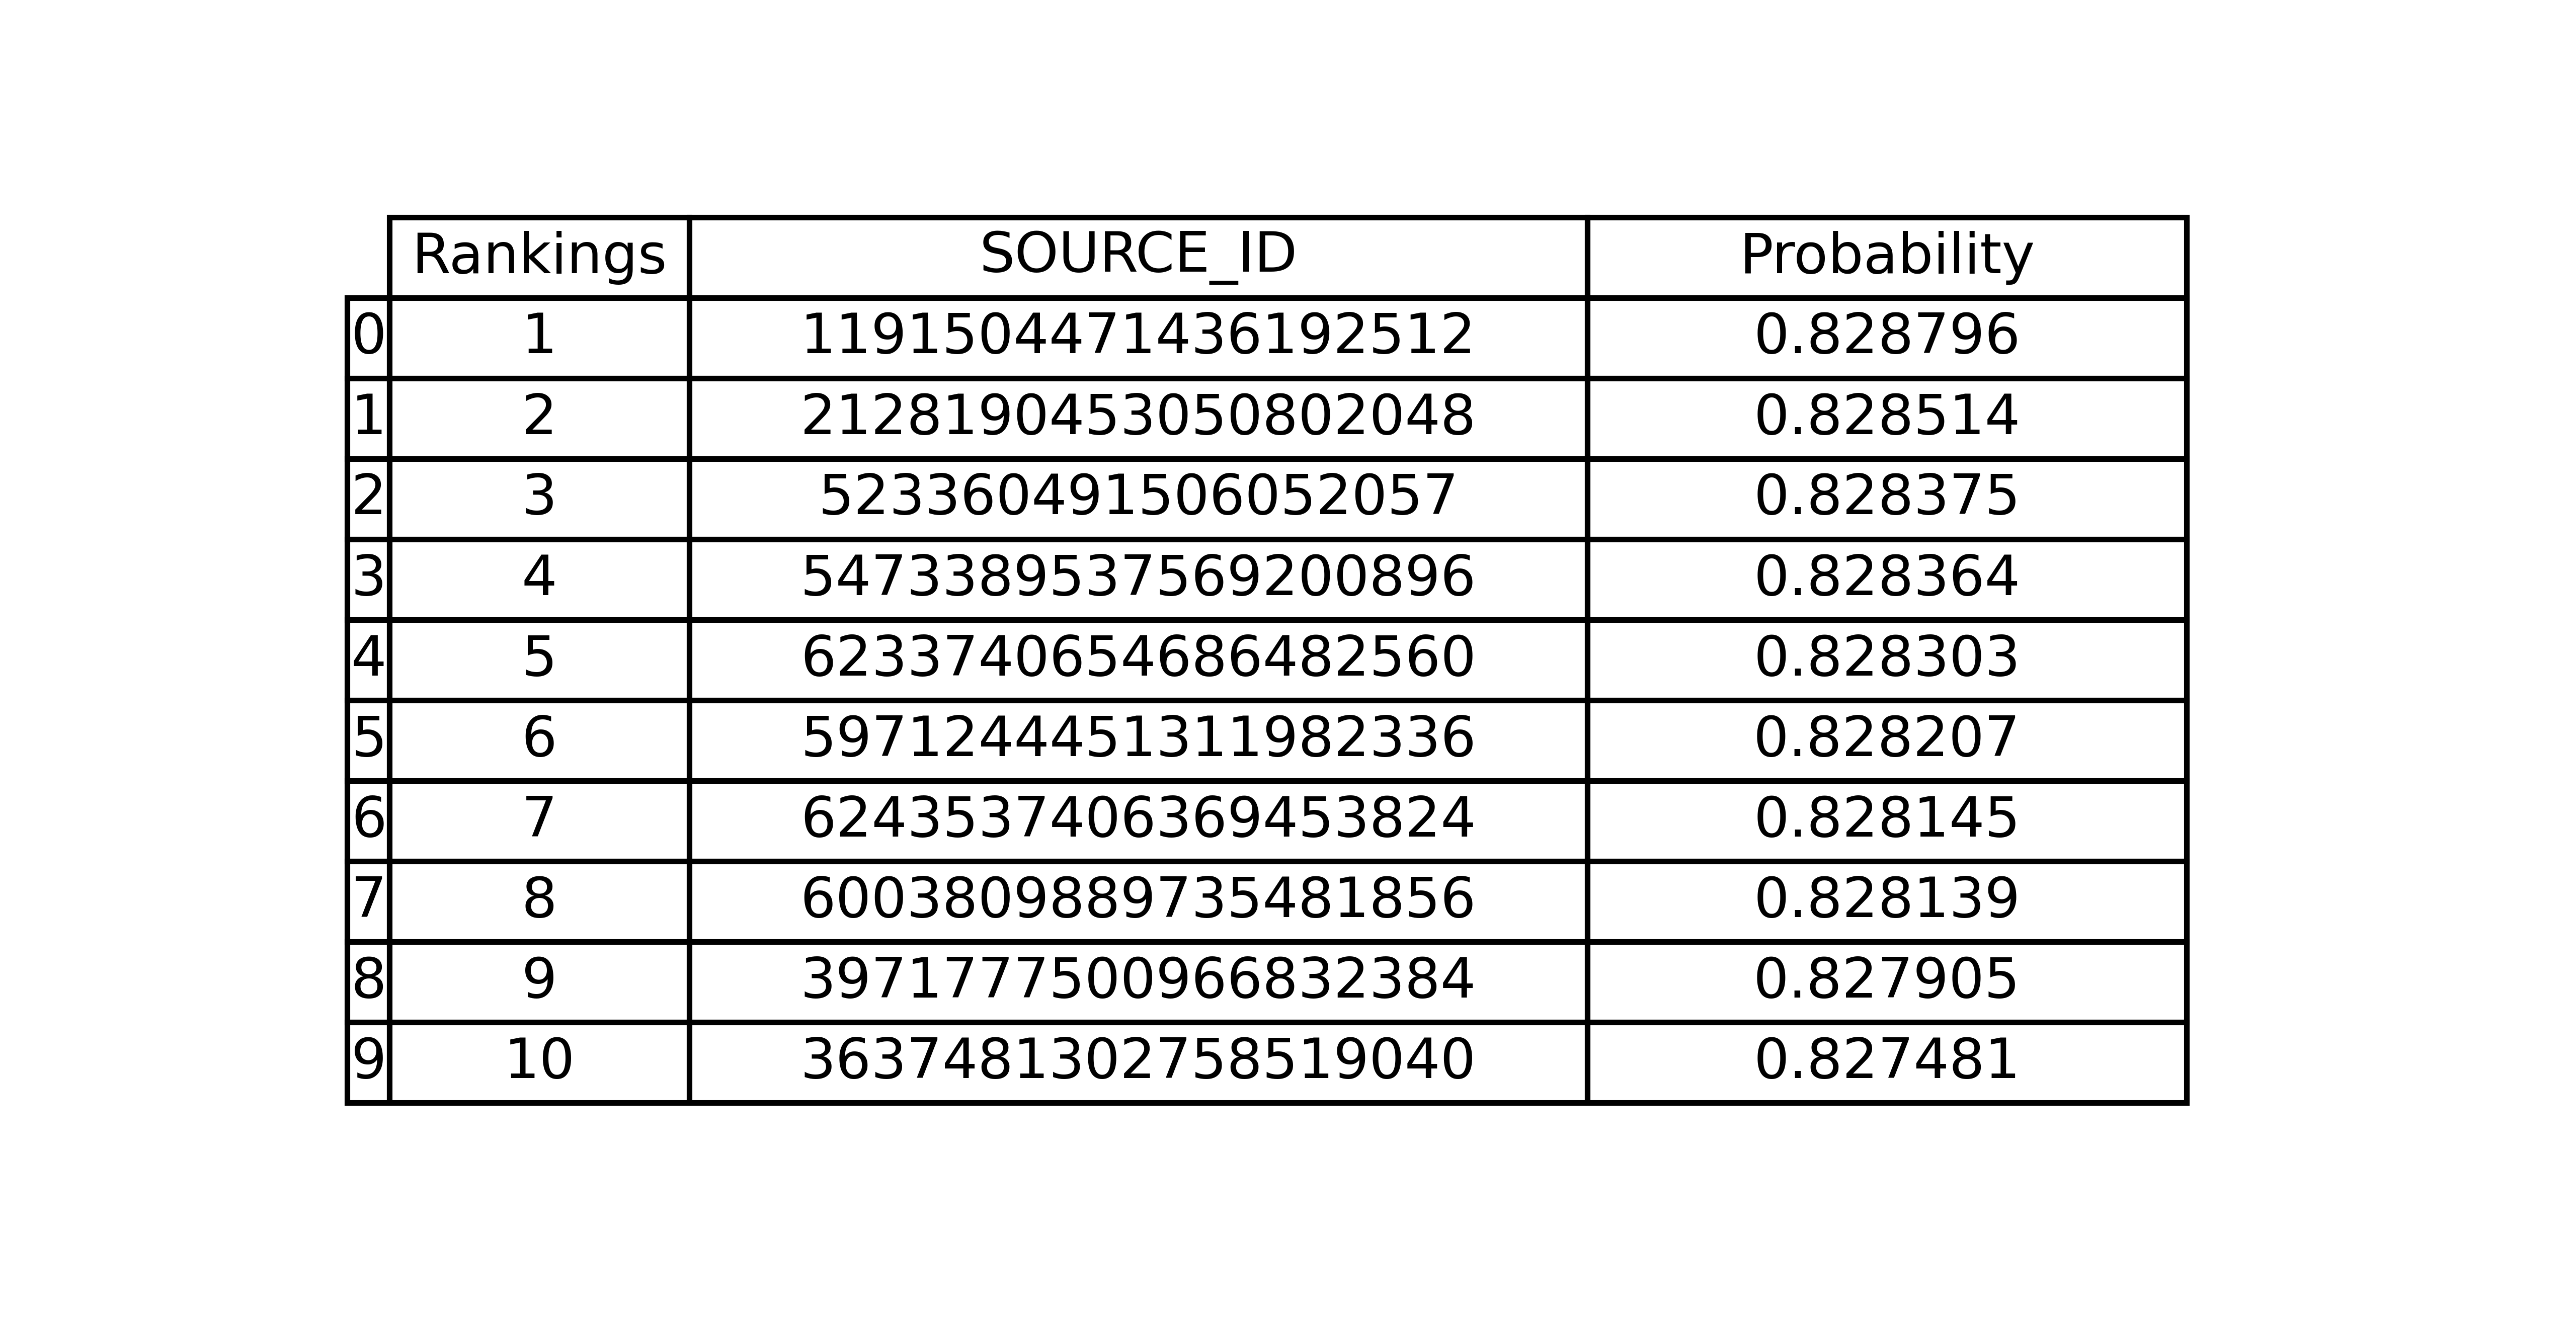

In [32]:
#cell 5

import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table

# Define the data for the table
data = {
    'Rankings': range(1, 11),
    'SOURCE_ID': [
        1191504471436192512,
        2128190453050802048,
        523360491506052057,
        5473389537569200896,
        6233740654686482560,
        5971244451311982336,
        6243537406369453824,
        6003809889735481856,
        3971777500966832384,
        3637481302758519040
    ],
    'Probability': [
        0.828796,
        0.828514,
        0.828375,
        0.828364,
        0.828303,
        0.828207,
        0.828145,
        0.828139,
        0.827905,
        0.827481
    ]
}

# Convert the dictionary to a DataFrame
df = pd.DataFrame(data)

# Convert SOURCE_ID to string to prevent scientific notation
df['SOURCE_ID'] = df['SOURCE_ID'].astype(str)

# Plot the table with the index included
fig, ax = plt.subplots(figsize=(8, 4), dpi=800)  # Set the figure size
ax.axis('off')  # Hide the axis
tbl = table(ax, df, loc='center', cellLoc='center', colWidths=[0.1, 0.3, 0.2])  # Create the table

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)  # Scale the table

plt.show()

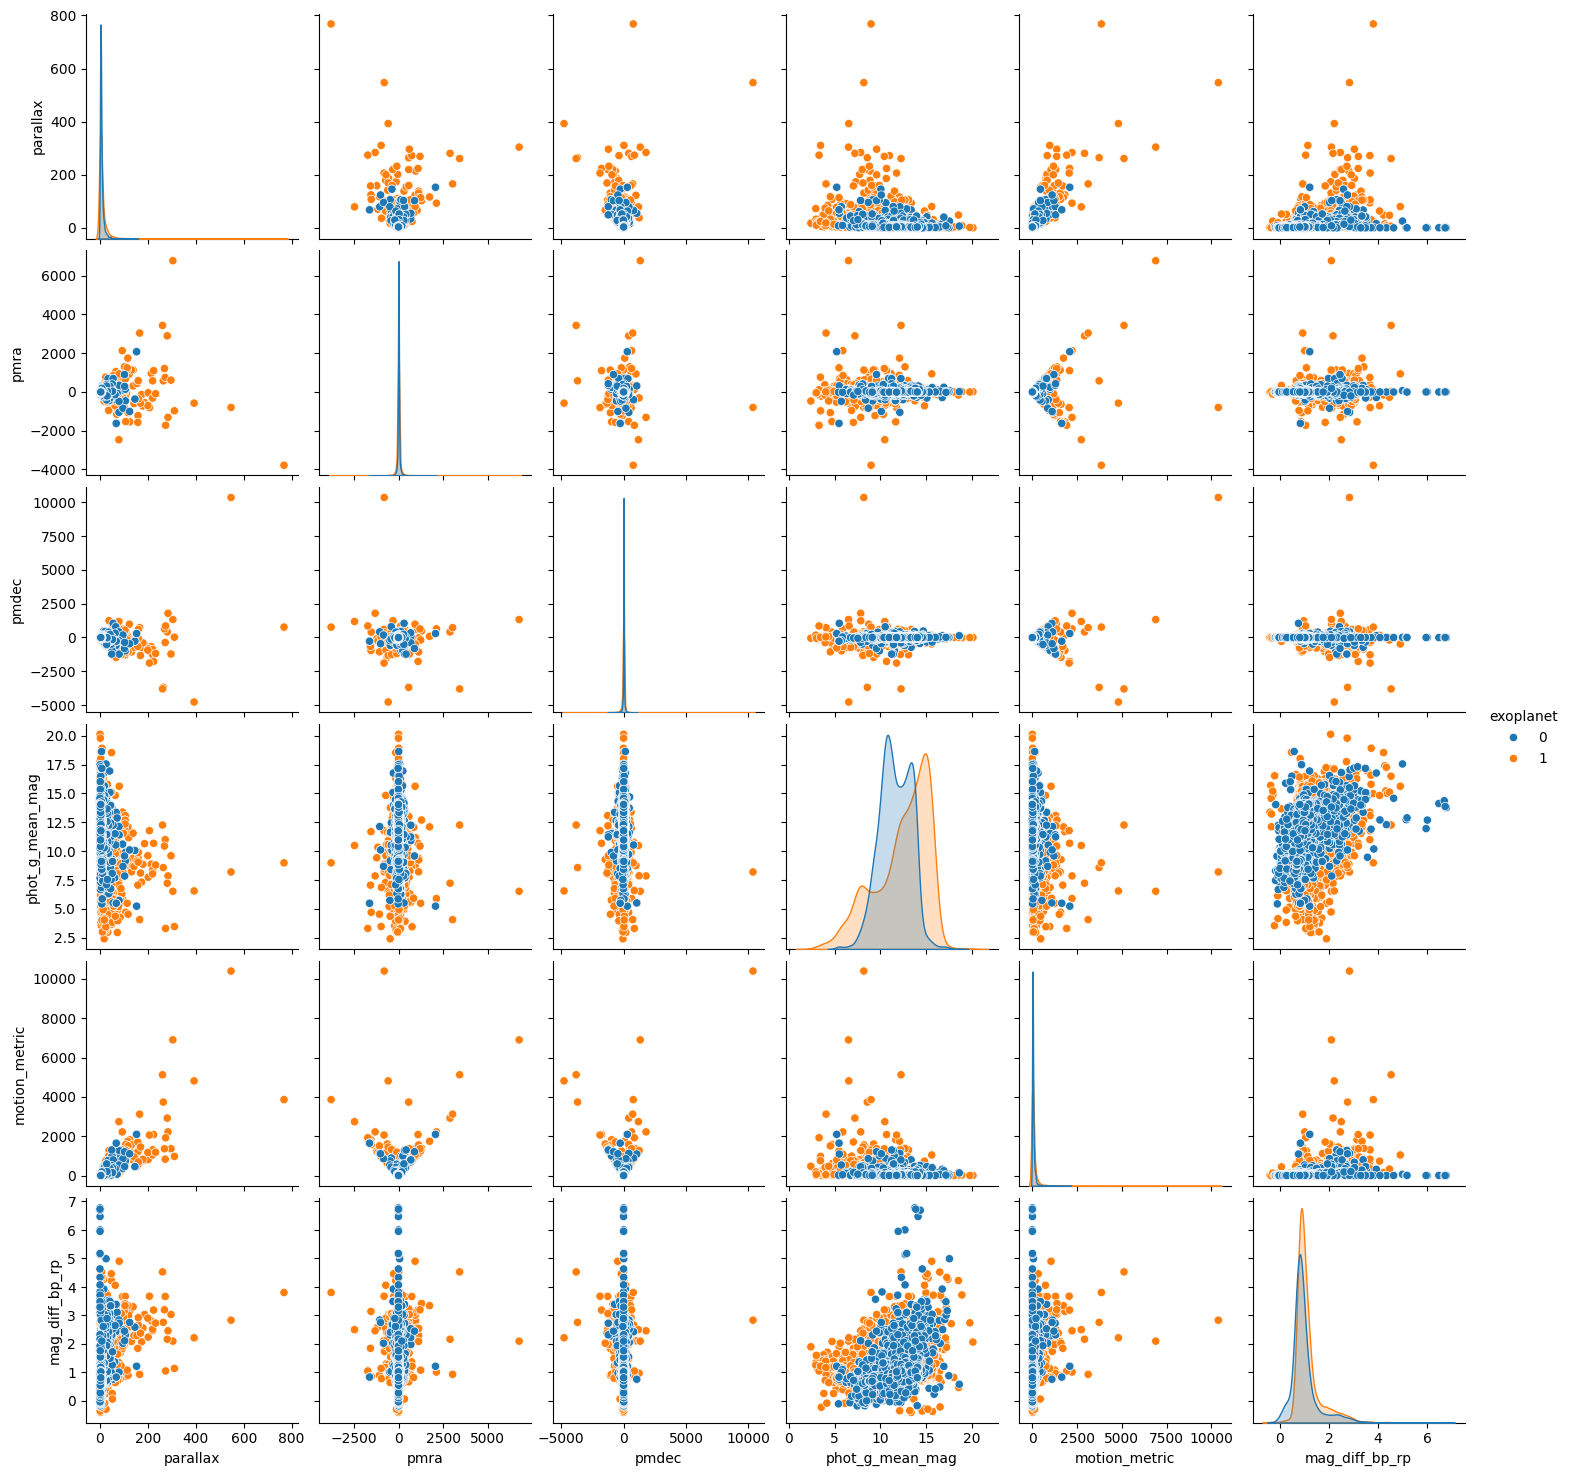

In [33]:
#Cell 6

def perform_eda(df):
    # Pairplot for initial visualization
    sns.pairplot(df[['parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'motion_metric', 'mag_diff_bp_rp', 'exoplanet']], hue='exoplanet')
    plt.show()

    # Check for correlations
    corr_matrix = df.corr()
    
    # Filter correlations to only include those between 0.1 and 0.85 (or -0.1 and -0.85)
    mask = ((corr_matrix >= 0.1) & (corr_matrix <= 0.85)) | ((corr_matrix <= -0.1) & (corr_matrix >= -0.85))
    
    # Identify the rows and columns to keep based on the mask
    rows_and_columns_to_keep = mask.any(axis=0) | mask.any(axis=1)
    
    # Filter the original correlation matrix to include only the relevant rows and columns
    filtered_corr_matrix = corr_matrix.loc[rows_and_columns_to_keep, rows_and_columns_to_keep]
    
    plt.figure(figsize=(12, 8), dpi=800)
    sns.heatmap(filtered_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
#     plt.savefig('heatmap_8k_false_positives_cut.jpeg', dpi=800, quality=95, format='jpeg')
    plt.show()

perform_eda(combined_data)

Raw feature importances:
                     Feature  Importance
            phot_rp_mean_mag    0.222841
             phot_g_mean_mag    0.172424
            phot_bp_mean_mag    0.132605
             radial_velocity    0.077259
        norm_radial_velocity    0.074785
astrometric_excess_noise_sig    0.065191
                 color_index    0.049266
                    parallax    0.040744
    astrometric_excess_noise    0.037309
              mag_diff_bp_rp    0.034397
          noise_signal_ratio    0.029618
               motion_metric    0.025592
                       pmdec    0.025232
                        pmra    0.008778
       parallax_motion_ratio    0.003959


C:\Users\Micah\AppData\Local\Temp\ipykernel_20492\1220038935.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Transformed Importance', y='Feature', data=feature_importance_df, palette='viridis')


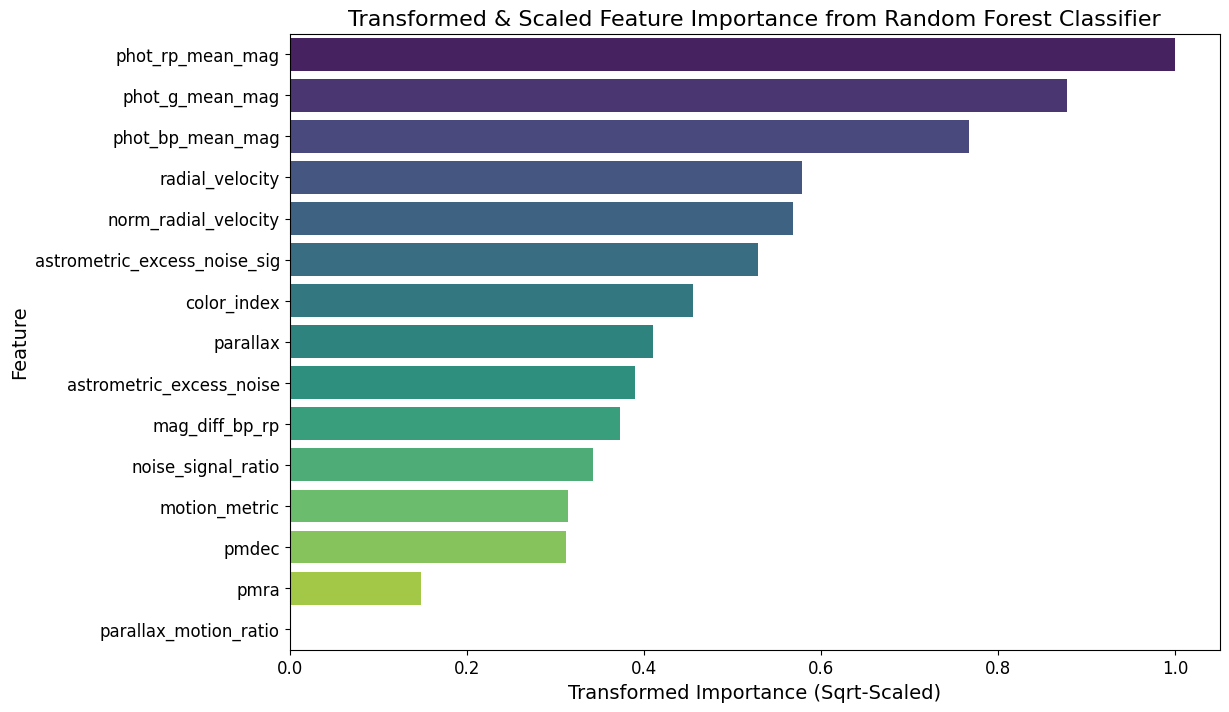

In [34]:
#Cell 7

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Assuming feature_importances contains the importance values from the Random Forest model
# Convert the feature importances into a Pandas DataFrame for easy plotting
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,  # Assuming X is your features DataFrame
    'Importance': best_model.feature_importances_
})

# Normalize the feature importances using MinMaxScaler
scaler = MinMaxScaler()
feature_importance_df['Scaled Importance'] = scaler.fit_transform(feature_importance_df[['Importance']])

# Square root transformation applied purely for visualization — compresses the gap
# between high and low importance values to make the chart more readable.
# Raw importances are printed below for scientific reproducibility.
feature_importance_df['Transformed Importance'] = feature_importance_df['Scaled Importance'] ** 0.5
print("Raw feature importances:")
print(feature_importance_df[['Feature', 'Importance']].sort_values('Importance', ascending=False).to_string(index=False))

# Sort the DataFrame by the transformed importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Transformed Importance', ascending=False)

# Plot the transformed feature importance using seaborn
plt.figure(figsize=(12, 8))
sns.barplot(x='Transformed Importance', y='Feature', data=feature_importance_df, palette='viridis')

# Add a title and labels to make the plot more informative
plt.title('Transformed & Scaled Feature Importance from Random Forest Classifier', fontsize=16)
plt.xlabel('Transformed Importance (Sqrt-Scaled)', fontsize=14)
plt.ylabel('Feature', fontsize=14)

# Increase the font size of the tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the plot as a high-resolution image
plt.savefig("transformed_feature_importance_barplot.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

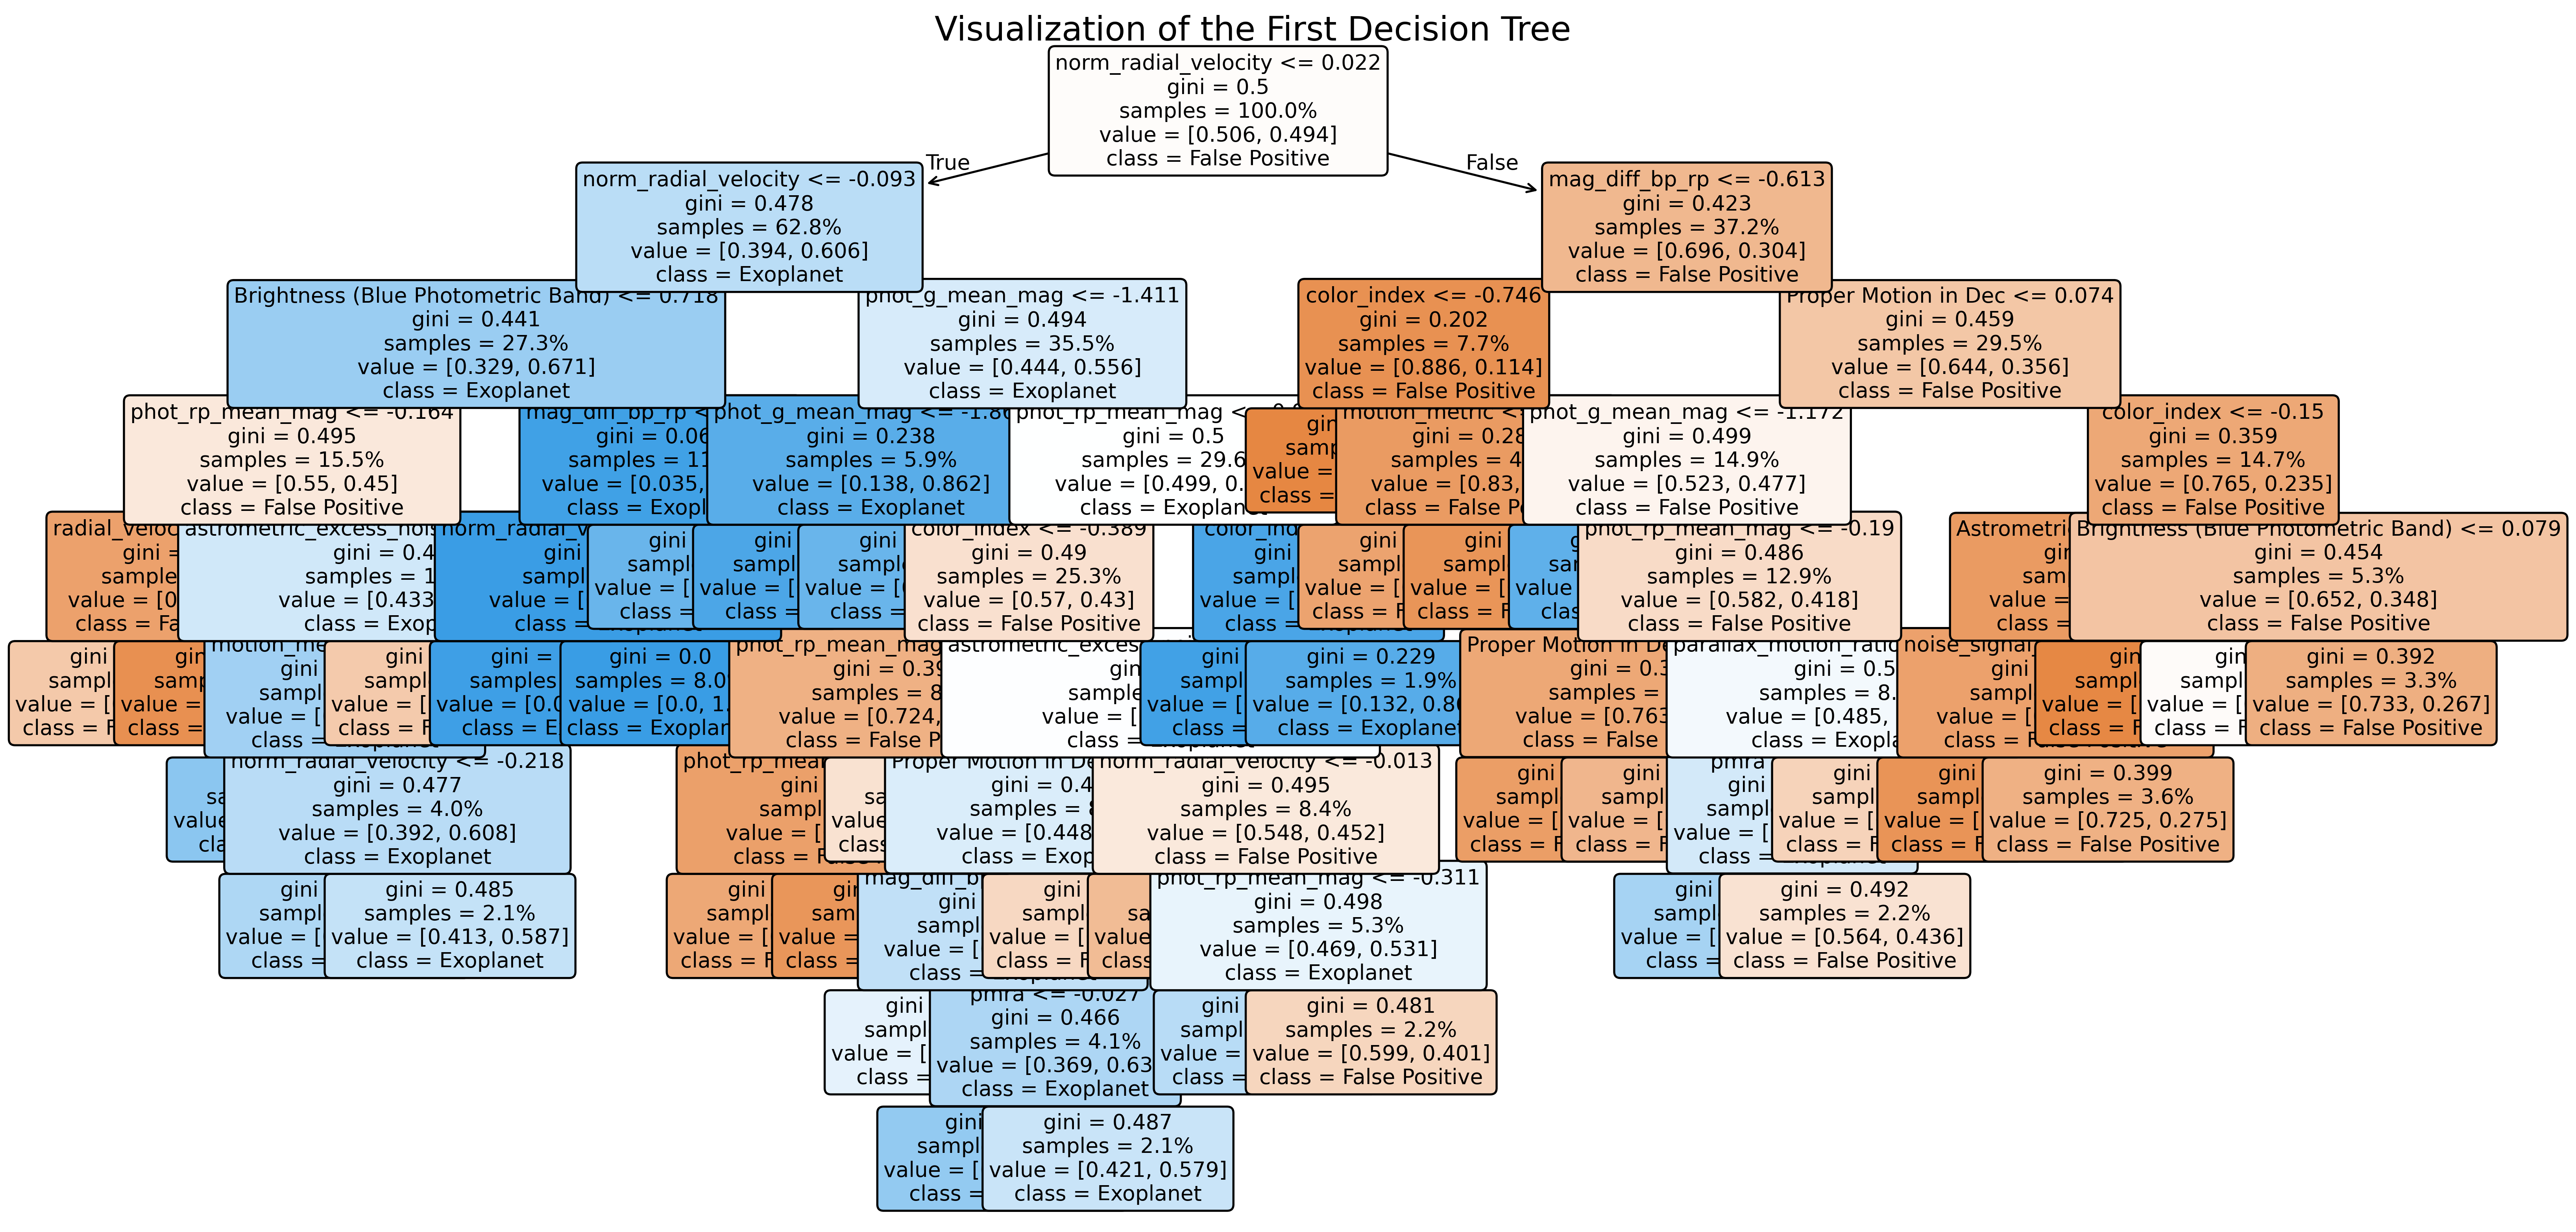

In [35]:
#Cell 8

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
%matplotlib inline


# Create a mapping of feature names to more understandable terms
feature_name_map = {
    'pmdec': 'Proper Motion in Dec',
    'phot_bp_mean_mag': 'Brightness (Blue Photometric Band)',
    'astrometric_excess_noise': 'Astrometric Noise',
    # Add more mappings if needed
}

# Create a mapping of class names for better understanding
class_name_map = {
    0: 'False Positive',
    1: 'Exoplanet'
}

# Function to plot the decision tree with simplified labels
def plot_simplified_tree(tree, feature_map, class_map):
    # Use the feature names and class names in the plot
    plt.figure(figsize=(20, 10), dpi=384)
    plot_tree(tree, 
              filled=True, 
              feature_names=[feature_map.get(f, f) for f in X.columns],  # Map feature names
              class_names=[class_map[0], class_map[1]],  # Map class names
              rounded=True, 
              fontsize=10, 
              proportion=True)
    plt.title("Visualization of the First Decision Tree", fontsize=16)
    plt.savefig("simplified_first_tree_visualization.png", dpi=300, format='png')

# Plot the tree with simplified labels
first_tree = best_model.estimators_[0]
plot_simplified_tree(first_tree, feature_name_map, class_name_map)


In [36]:
#Cell 9

import seaborn as sns

# Save pairplot as an 8K JPEG with the same scale
pairplot_fig = sns.pairplot(combined_data[['parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'motion_metric', 'mag_diff_bp_rp', 'exoplanet']], hue='exoplanet')
pairplot_fig.fig.tight_layout(pad=2.0)  # Adjust padding
# pairplot_fig.savefig('pairplot_8k_false_positives.jpeg', dpi=800, quality=95, format='jpeg')
plt.close()

# Save heatmap as an 8K JPEG with the same scale
corr_matrix = combined_data.corr()
heatmap_fig, ax = plt.subplots(figsize=(12, 8))  # Keep the same figure size
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax)
heatmap_fig.tight_layout(pad=2.0)  # Adjust padding
# heatmap_fig.savefig('heatmap_8k_false_positives.jpeg', dpi=800, quality=95, format='jpeg')
plt.close()

Confirmed planet hosts: 4154
TOI false positives:    3636
Combined dataset:       7790


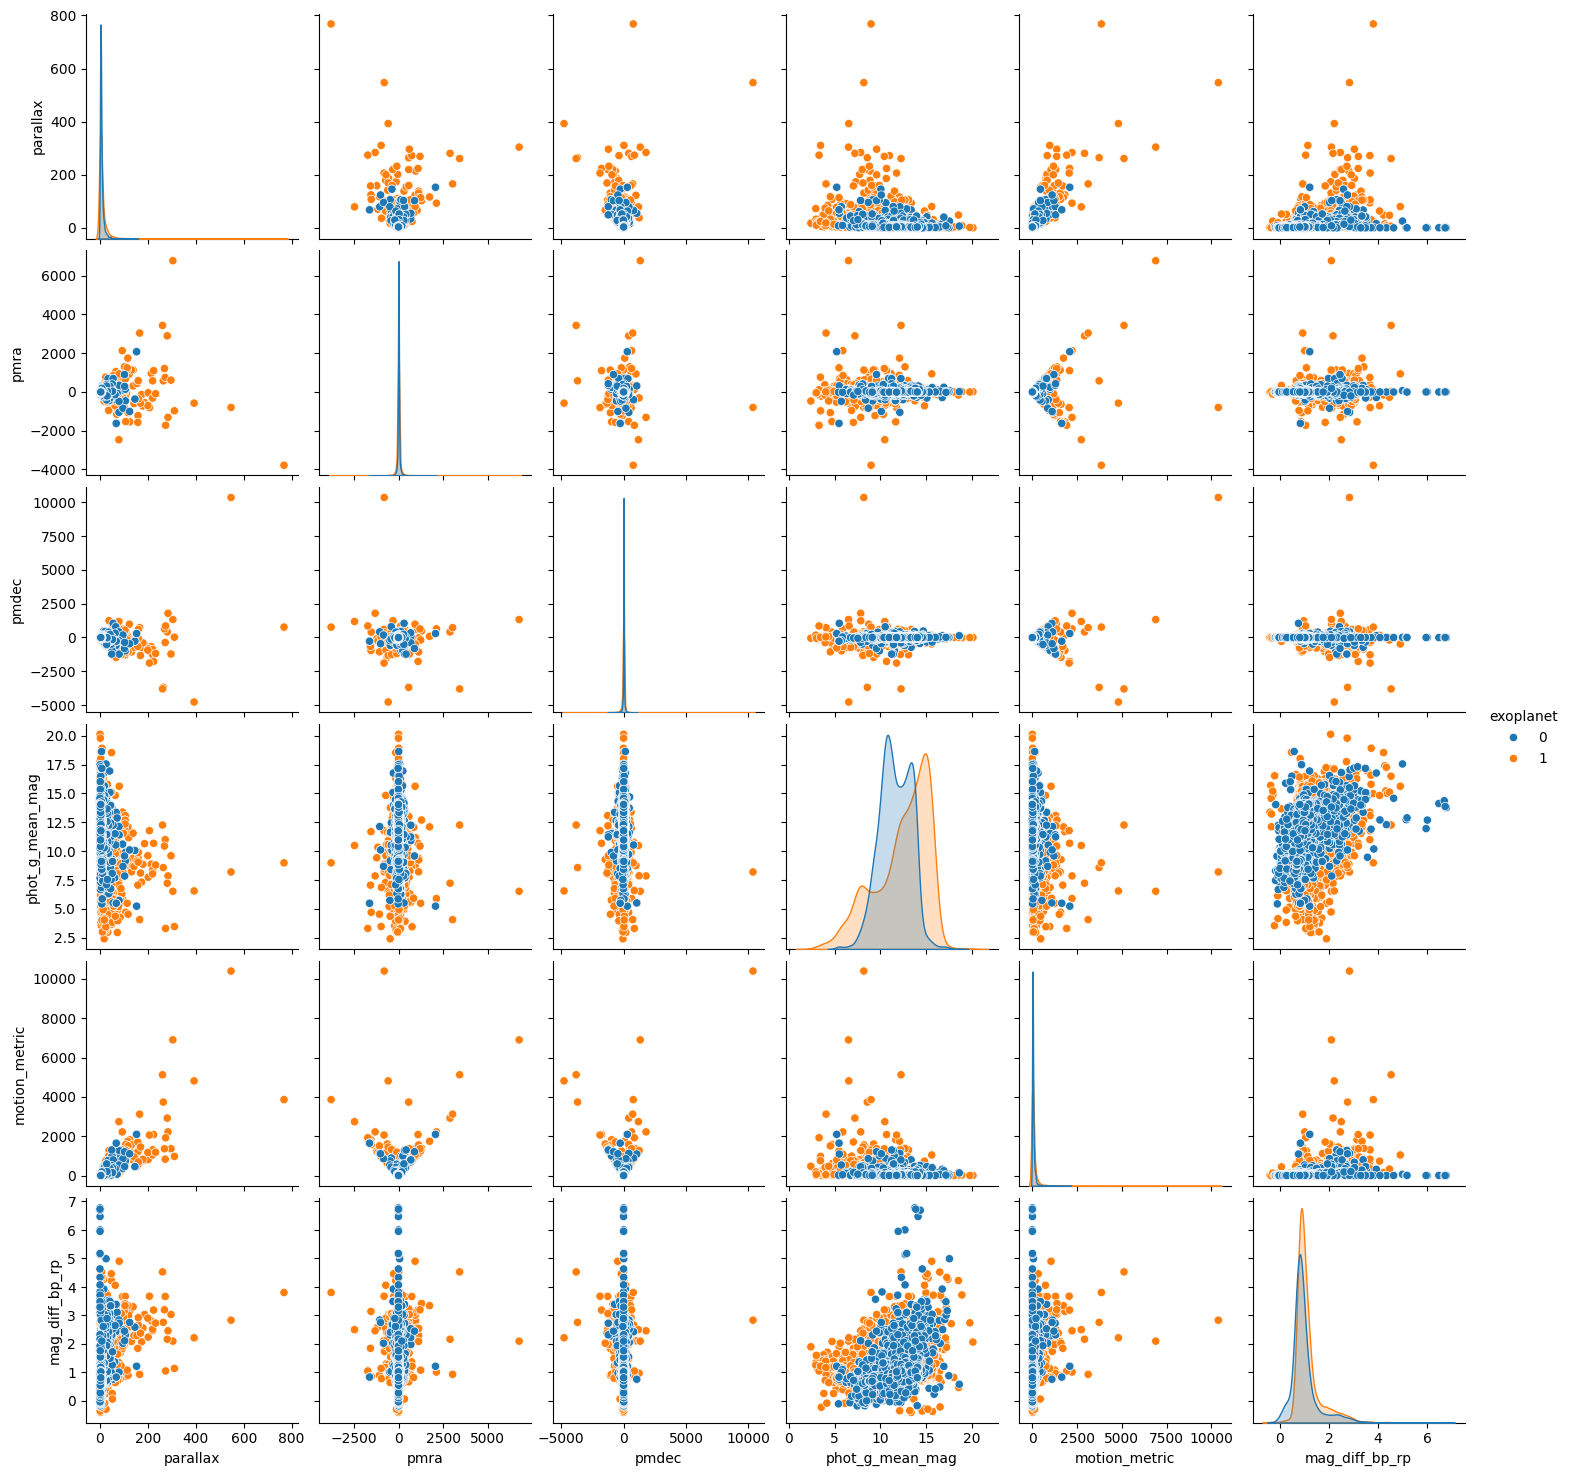

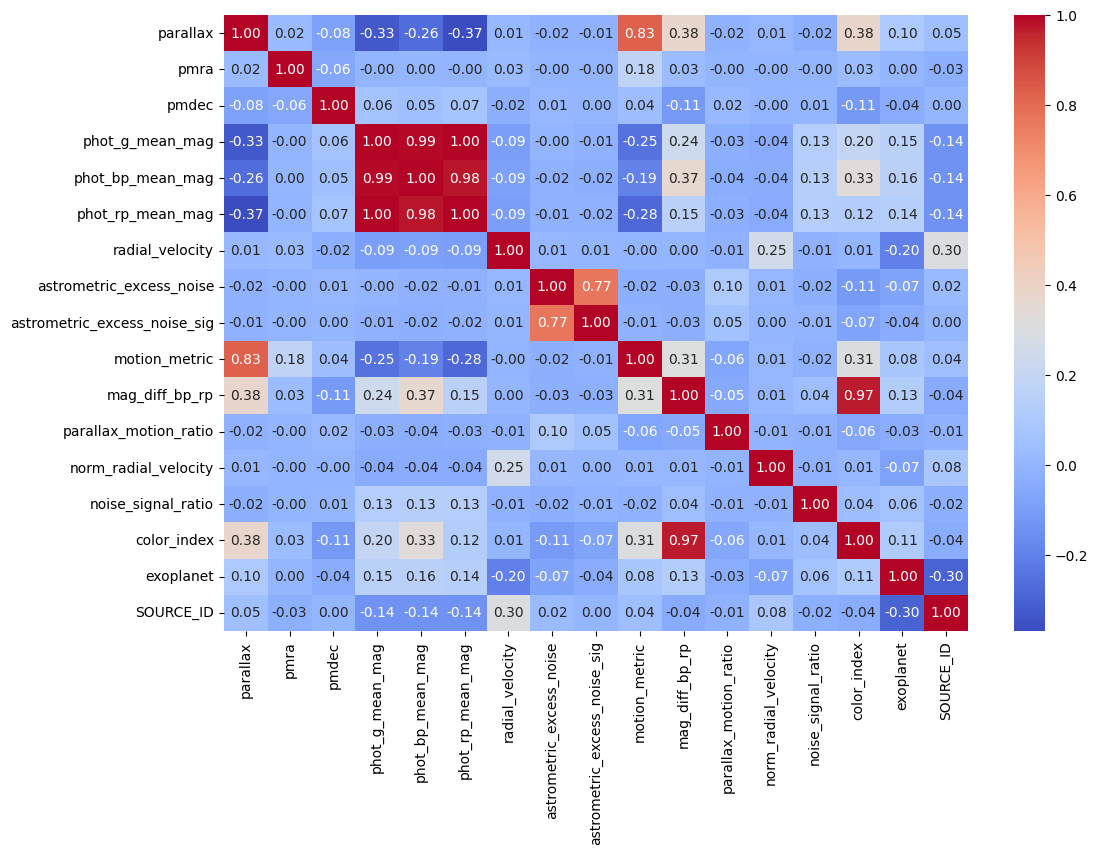

Target distribution before SMOTE: exoplanet
1    3295
0    2937
Name: count, dtype: int64
Target distribution after SMOTE: (array([0, 1]), array([3295, 3295]))
Shape of X_train_balanced: (6590, 15)
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Cross-validated ROC AUC scores: [0.84644044 0.84445555 0.84498286 0.85122766 0.85043785]
Mean ROC AUC score: 0.8475088709844547
              precision    recall  f1-score   support

           0       0.68      0.85      0.75       699
           1       0.84      0.67      0.75       859

    accuracy                           0.75      1558
   macro avg       0.76      0.76      0.75      1558
weighted avg       0.77      0.75      0.75      1558

ROC AUC Score on test set: 0.8533661092430398
Feature importances:
 phot_rp_mean_mag                0.222841
phot_g_mean_mag                 0.172424
phot_bp_mean_mag                0.132605
radial_velocity                 0.077259
norm_radial_velocity            0.074785
astrometric_e

In [37]:
# Cell 10 — Alternative ML Pipeline (Fixed)

import pandas as pd
import numpy as np
import joblib
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocess GAIA data — imputation only, scaling happens after the split
def preprocess_data(df):
    SOURCE_IDs = df['SOURCE_ID']
    df = df.drop('SOURCE_ID', axis=1)
    imputer = SimpleImputer(strategy='median')
    df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
    df_imputed['SOURCE_ID'] = SOURCE_IDs.values
    return df_imputed

# Load confirmed planets — same as Cell 3
confirmed_planets_data = pd.read_csv('gaia_query_results.csv')
confirmed_data = preprocess_data(confirmed_planets_data)
confirmed_data['exoplanet'] = 1

# Load TOI false positives — replacing the arbitrary Gaia stars
# that were previously used as the negative class
false_positives_data = pd.read_csv('gaia_data_results.csv')
false_positives_data = preprocess_data(false_positives_data)
false_positives_data['exoplanet'] = 0

combined_data = pd.concat([confirmed_data, false_positives_data], ignore_index=True)

print(f"Confirmed planet hosts: {confirmed_data.shape[0]}")
print(f"TOI false positives:    {false_positives_data.shape[0]}")
print(f"Combined dataset:       {combined_data.shape[0]}")

# Feature engineering
def feature_engineering(df):
    df['motion_metric'] = np.sqrt(df['pmra']**2 + df['pmdec']**2)
    df['mag_diff_bp_rp'] = df['phot_bp_mean_mag'] - df['phot_rp_mean_mag']
    df['parallax_motion_ratio'] = df['parallax'] / df['motion_metric'].replace(0, np.nan)
    df['norm_radial_velocity'] = df['radial_velocity'] / df['parallax'].replace(0, np.nan)
    df['noise_signal_ratio'] = df['astrometric_excess_noise'] / df['astrometric_excess_noise_sig'].replace(0, np.nan)
    df['color_index'] = df['phot_bp_mean_mag'] - df['phot_g_mean_mag']
    return df

combined_data = feature_engineering(combined_data)

# Clean up NaN/Inf from engineered features
combined_data = combined_data.replace([np.inf, -np.inf], np.nan)
source_ids_backup = combined_data['SOURCE_ID']
labels_backup = combined_data['exoplanet']

model_columns = [
    'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'radial_velocity',
    'astrometric_excess_noise', 'astrometric_excess_noise_sig', 'motion_metric', 'mag_diff_bp_rp',
    'parallax_motion_ratio', 'norm_radial_velocity', 'noise_signal_ratio', 'color_index'
]

imputer_features = SimpleImputer(strategy='median')
combined_data[model_columns] = imputer_features.fit_transform(combined_data[model_columns])
combined_data['SOURCE_ID'] = source_ids_backup.values
combined_data['exoplanet'] = labels_backup.values
combined_data = combined_data[model_columns + ['exoplanet', 'SOURCE_ID']]

# EDA
def perform_eda(df):
    sns.pairplot(df[['parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'motion_metric', 'mag_diff_bp_rp', 'exoplanet']], hue='exoplanet')
    plt.show()
    corr_matrix = df.corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.show()

perform_eda(combined_data)

X = combined_data.drop(['exoplanet', 'SOURCE_ID'], axis=1)
y = combined_data['exoplanet']

# STEP 1: Split first, before any scaling or SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 2: Fit scaler on training data only, then apply to both sets
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

# Final NaN cleanup after scaling
imputer_final = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer_final.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer_final.transform(X_test),      columns=X_test.columns)

# Save this cell's scaler separately so it doesn't overwrite Cell 3's
joblib.dump(scaler, 'training_scaler_cell10.pkl')

# STEP 3: Apply SMOTE to training data only
print("Target distribution before SMOTE:", y_train.value_counts())
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print("Target distribution after SMOTE:", np.unique(y_train_balanced, return_counts=True))
print("Shape of X_train_balanced:", X_train_balanced.shape)

# Hyperparameter tuning
param_grid = {
    'n_estimators': [5000, 6000],
    'max_depth': [5, 10],
    'min_samples_split': [10, 15],
    'min_samples_leaf': [80, 100]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_balanced, y_train_balanced)

cv_scores = cross_val_score(grid_search.best_estimator_, X_train_balanced, y_train_balanced, cv=5, scoring='roc_auc')
print("Cross-validated ROC AUC scores:", cv_scores)
print("Mean ROC AUC score:", np.mean(cv_scores))

# STEP 4: Evaluate on the original, untouched test set
best_model_cell10 = grid_search.best_estimator_
y_pred = best_model_cell10.predict(X_test)
y_pred_proba = best_model_cell10.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC Score on test set:", roc_auc_score(y_test, y_pred_proba))

feature_importances = pd.Series(best_model_cell10.feature_importances_, index=X_train.columns)
print("Feature importances:\n", feature_importances.sort_values(ascending=False))

X_full = combined_data[model_columns]
combined_data['probability'] = best_model_cell10.predict_proba(X_full)[:, 1]

# Show top confirmed planet hosts by score — for model validation only
# Genuine novel candidates come from Cells 12 and 13
top_candidates = combined_data[combined_data['exoplanet'] == 1].nlargest(10, 'probability')
print("Top 10 Highest-Scoring Confirmed Exoplanet Hosts (validation check):")
print(top_candidates[['SOURCE_ID', 'probability']])

In [38]:
#Cell 11

import seaborn as sns

pairplot_fig = sns.pairplot(combined_data[['parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'motion_metric', 'mag_diff_bp_rp', 'exoplanet']], hue='exoplanet')
pairplot_fig.fig.tight_layout(pad=2.0)
# pairplot_fig.savefig('pairplot_8k_false_positives.jpeg', dpi=800, format='jpeg')  # save before close
plt.close()

# Save heatmap as an 8K JPEG with the same scale
corr_matrix = combined_data.corr()
heatmap_fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax)
heatmap_fig.tight_layout(pad=2.0)
# heatmap_fig.savefig('heatmap_8k_false_positives.jpeg', dpi=800, format='jpeg')  # save before close
plt.close()

In [39]:
# Cell 12 — Large-Scale Inference on 250,000 Gaia Stars

import numpy as np
import pandas as pd
import joblib
from sklearn.impute import SimpleImputer
from astroquery.gaia import Gaia

def query_gaia_data(query):
    job = Gaia.launch_job(query)
    results = job.get_results()
    return results.to_pandas()

# Query to fetch the first 1000 rows
query_first_1000 = """
SELECT TOP 1000 
    source_id AS SOURCE_ID, parallax, pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, radial_velocity, 
    astrometric_excess_noise, astrometric_excess_noise_sig
FROM gaiadr3.gaia_source
WHERE parallax IS NOT NULL
AND pmra IS NOT NULL
AND pmdec IS NOT NULL
AND phot_g_mean_mag IS NOT NULL
AND phot_bp_mean_mag IS NOT NULL
AND phot_rp_mean_mag IS NOT NULL
AND radial_velocity IS NOT NULL
AND astrometric_excess_noise IS NOT NULL
AND astrometric_excess_noise_sig IS NOT NULL
ORDER BY source_id
"""

first_1000_data = query_gaia_data(query_first_1000)
max_source_id = first_1000_data['SOURCE_ID'].max()

query_next_250000 = f"""
SELECT TOP 250000
    source_id AS SOURCE_ID, parallax, pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, radial_velocity, 
    astrometric_excess_noise, astrometric_excess_noise_sig
FROM gaiadr3.gaia_source
WHERE source_id > {max_source_id}
AND parallax IS NOT NULL
AND pmra IS NOT NULL
AND pmdec IS NOT NULL
AND phot_g_mean_mag IS NOT NULL
AND phot_bp_mean_mag IS NOT NULL
AND phot_rp_mean_mag IS NOT NULL
AND radial_velocity IS NOT NULL
AND astrometric_excess_noise IS NOT NULL
AND astrometric_excess_noise_sig IS NOT NULL
ORDER BY source_id
"""

next_250000_data = query_gaia_data(query_next_250000)

# Preprocess — imputation only, no scaling here
def preprocess_data(df):
    SOURCE_IDs = df['SOURCE_ID']
    df = df.drop('SOURCE_ID', axis=1)
    imputer = SimpleImputer(strategy='median')
    df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
    df_imputed['SOURCE_ID'] = SOURCE_IDs.values
    return df_imputed

# Feature engineering — matches Cell 3 exactly, no duplicate total_proper_motion
def feature_engineering(df):
    df['motion_metric'] = np.sqrt(df['pmra']**2 + df['pmdec']**2)
    df['mag_diff_bp_rp'] = df['phot_bp_mean_mag'] - df['phot_rp_mean_mag']
    df['parallax_motion_ratio'] = df['parallax'] / df['motion_metric'].replace(0, np.nan)
    df['norm_radial_velocity'] = df['radial_velocity'] / df['parallax'].replace(0, np.nan)
    df['noise_signal_ratio'] = df['astrometric_excess_noise'] / df['astrometric_excess_noise_sig'].replace(0, np.nan)
    df['color_index'] = df['phot_bp_mean_mag'] - df['phot_g_mean_mag']
    return df

model_columns = [
    'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'radial_velocity',
    'astrometric_excess_noise', 'astrometric_excess_noise_sig', 'motion_metric', 'mag_diff_bp_rp',
    'parallax_motion_ratio', 'norm_radial_velocity', 'noise_signal_ratio', 'color_index'
]

# Step 1: Preprocess and engineer features
new_data_preprocessed = preprocess_data(next_250000_data)
new_data_features = feature_engineering(new_data_preprocessed)

# Step 2: Clean up NaN/Inf from engineered features
new_data_features = new_data_features.replace([np.inf, -np.inf], np.nan)

# Step 3: Extract model columns
X_new = new_data_features[model_columns]

# Step 4: Impute any remaining NaN, then apply the training scaler
imputer_inf = SimpleImputer(strategy='median')
X_new = pd.DataFrame(imputer_inf.fit_transform(X_new), columns=X_new.columns)
scaler = joblib.load('training_scaler.pkl')
X_new = pd.DataFrame(scaler.transform(X_new), columns=X_new.columns)

# Load the trained model from Cell 3
best_model = joblib.load('best_model.pkl')

# Predict probabilities on the new dataset
next_250000_data['probability'] = best_model.predict_proba(X_new)[:, 1]

# Top 10 novel candidates
top_new_candidates = next_250000_data.nlargest(10, 'probability')
print("Top 10 New Exoplanet Candidates:")
print(top_new_candidates[['SOURCE_ID', 'probability']])

# Save inference results for Cell 13
next_250000_data.to_csv('cell12_inference_results.csv', index=False)
print("Saved inference results to cell12_inference_results.csv")

Top 10 New Exoplanet Candidates:
                 SOURCE_ID  probability
188642  120090927728432128     0.993026
152702  100451420968954752     0.993015
152452  100274090359186304     0.993004
81182    56970237217611648     0.992994
122875   78546636787468800     0.992925
167763  109415979788504704     0.992878
60088    46488146193667456     0.992834
224869  136776124055379456     0.992820
106481   68921825531469056     0.992811
85400    59303572689531392     0.992741
Saved inference results to cell12_inference_results.csv


In [40]:
# Cell 13 — Analysis on Cell 12 Results (reads from locally saved CSV)

import pandas as pd
import numpy as np
import joblib
from sklearn.impute import SimpleImputer

# Read the saved results from Cell 12
all_csv_data = pd.read_csv('cell12_inference_results.csv')
csv_data = all_csv_data.copy()

print(f"Loaded {len(csv_data)} stars from Cell 12 results")
print(f"Probability range: {csv_data['probability'].min():.4f} — {csv_data['probability'].max():.4f}")

# Top 10 candidates
top_new_candidates = csv_data.nlargest(10, 'probability')
print("\nTop 10 New Exoplanet Candidates:")
print(top_new_candidates[['SOURCE_ID', 'probability']])

# Distribution of probability scores
print(f"\nProbability distribution:")
print(f"  Mean:   {csv_data['probability'].mean():.4f}")
print(f"  Median: {csv_data['probability'].median():.4f}")
print(f"  Std:    {csv_data['probability'].std():.4f}")
print(f"  Stars above 0.75: {(csv_data['probability'] > 0.75).sum()}")
print(f"  Stars above 0.80: {(csv_data['probability'] > 0.80).sum()}")
print(f"  Stars above 0.85: {(csv_data['probability'] > 0.85).sum()}")

Loaded 250000 stars from Cell 12 results
Probability range: 0.0378 — 0.9930

Top 10 New Exoplanet Candidates:
                 SOURCE_ID  probability
188642  120090927728432128     0.993026
152702  100451420968954752     0.993015
152452  100274090359186304     0.993004
81182    56970237217611648     0.992994
122875   78546636787468800     0.992925
167763  109415979788504704     0.992878
60088    46488146193667456     0.992834
224869  136776124055379456     0.992820
106481   68921825531469056     0.992811
85400    59303572689531392     0.992741

Probability distribution:
  Mean:   0.5828
  Median: 0.6038
  Std:    0.2348
  Stars above 0.75: 55721
  Stars above 0.80: 50349
  Stars above 0.85: 44731


In [41]:
import joblib
scaler = joblib.load('training_scaler.pkl')
print(f"Scaler expects {scaler.n_features_in_} features")
print(f"Feature names: {list(scaler.feature_names_in_)}")

Scaler expects 15 features
Feature names: ['parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'radial_velocity', 'astrometric_excess_noise', 'astrometric_excess_noise_sig', 'motion_metric', 'mag_diff_bp_rp', 'parallax_motion_ratio', 'norm_radial_velocity', 'noise_signal_ratio', 'color_index']


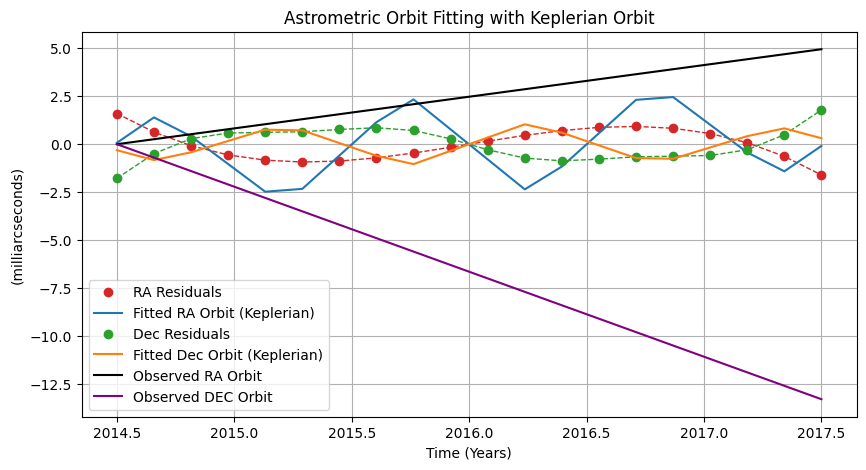

Improved Fitted Parameters for RA: [ 4.00944990e+00  5.94085207e-01  5.09173481e-01  1.62120884e+00
  3.08661541e+00  1.16262959e+00  2.01425635e+03 -6.72087736e-03]
Improved Fitted Parameters for Dec: [8.06677241e-02 1.94036941e-03 2.59771982e+00 5.09354492e+00
 2.43053742e-01 3.18829216e-01 2.01173664e+03 1.07184755e+00]


In [42]:
#Cell 14

import numpy as np
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia
from astropy.time import Time
from scipy.optimize import curve_fit
%matplotlib inline

# Source ID for the candidate
source_id = '53009212219874304'

def get_gaia_data(source_id):
    """
    Query Gaia data for a given source ID.
    """
    query = f"""
    SELECT ra, dec, parallax, pmra, pmdec, radial_velocity, ref_epoch
    FROM gaiadr3.gaia_source
    WHERE source_id = {source_id}
    """
    job = Gaia.launch_job(query)
    result = job.get_results()
    return result[0]

def compute_position(ra, dec, pmra, pmdec, ref_epoch, epochs):
    """
    Compute observed RA and Dec positions based on proper motion.
    """
    ra_rad = np.deg2rad(ra)
    dec_rad = np.deg2rad(dec)
    pmra_rad = np.deg2rad(pmra / 3600)
    pmdec_rad = np.deg2rad(pmdec / 3600)

    positions = []
    for epoch in epochs:
        delta_t = epoch - ref_epoch
        ra_new = ra_rad + pmra_rad * delta_t
        dec_new = dec_rad + pmdec_rad * delta_t
        positions.append((np.rad2deg(ra_new), np.rad2deg(dec_new)))
    return positions

# Get Gaia data for the source
gaia_data = get_gaia_data(source_id)

# Extract data for further analysis
ra = gaia_data['ra']
dec = gaia_data['dec']
pmra = gaia_data['pmra']
pmdec = gaia_data['pmdec']
parallax = gaia_data['parallax']
ref_epoch = gaia_data['ref_epoch']

# Define the observation epochs (e.g., from 2014.5 to 2017.5)
epochs = np.linspace(2014.5, 2017.5, 20)

# Compute observed RA and Dec positions
observed_positions = compute_position(ra, dec, pmra, pmdec, ref_epoch, epochs)

# Extract RA and Dec for the observed positions
observed_ra, observed_dec = zip(*observed_positions)

# Convert observed positions to milliarcseconds for consistency
observed_ra = np.array(observed_ra) * 1000
observed_dec = np.array(observed_dec) * 1000

# Original time range for fitting (±5 years around ref_epoch)
time_years_full = np.linspace(ref_epoch - 5, ref_epoch + 5, 20)  # Full time range for the model

# Calculate predicted RA and Dec based on proper motion (over full time range)
predicted_ra_full = observed_ra + pmra * (time_years_full - ref_epoch)
predicted_dec_full = observed_dec + pmdec * (time_years_full - ref_epoch)

# Calculate residuals (over full time range)
ra_residuals_full = observed_ra - predicted_ra_full
dec_residuals_full = observed_dec - predicted_dec_full

# Query Gaia Archive for the astrometric data of the given source ID
job = Gaia.launch_job(f"""
SELECT
    ra, dec, ref_epoch, pmra, pmdec, parallax
FROM gaiadr3.gaia_source
WHERE source_id = {source_id}
""")
result = job.get_results()

# Extract data from the query result
ra_data = result['ra'].data[0] * 1000  # Convert to milliarcseconds
dec_data = result['dec'].data[0] * 1000  # Convert to milliarcseconds
ref_epoch = result['ref_epoch'].data[0]
pmra = result['pmra'].data[0]
pmdec = result['pmdec'].data[0]
parallax = result['parallax'].data[0]

# Time range for fitting (scaled to the desired time range 2014.5-2017.5)
time_years_scaled = np.linspace(2014.5, 2017.5, 20)

# Calculate predicted RA and Dec based on proper motion
predicted_ra_full = ra_data + pmra * (time_years_scaled - ref_epoch)
predicted_dec_full = dec_data + pmdec * (time_years_scaled - ref_epoch)

# Define a full Keplerian orbital model including parallax
def keplerian_orbit(t, a, e, i, omega, Omega, P, T0, parallax):
    """
    Full Keplerian model for astrometric orbit including parallax.
    
    t: time in years
    a: semi-major axis (milliarcseconds)
    e: eccentricity
    i: inclination (radians)
    omega: argument of periapsis (radians)
    Omega: longitude of ascending node (radians)
    P: orbital period (years)
    T0: time of periapsis passage (years)
    parallax: parallax (milliarcseconds)
    
    Returns:
    ra_total, dec_total: RA and Dec offsets (milliarcseconds)
    """
    # Mean anomaly
    M = 2 * np.pi * (t - T0) / P
    
    # Eccentric anomaly using Newton's method
    E = M  # Initial guess for eccentric anomaly
    for _ in range(10):
        E = M + e * np.sin(E)
    
    # True anomaly
    nu = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2), np.sqrt(1 - e) * np.cos(E / 2))
    
    # Orbital positions in the orbital plane
    r = a * (1 - e * np.cos(E))
    x_orbit = r * np.cos(nu)
    y_orbit = r * np.sin(nu)
    
    # Convert to sky coordinates
    x_sky = x_orbit * (np.cos(omega) * np.cos(Omega) - np.sin(omega) * np.sin(Omega) * np.cos(i)) \
          - y_orbit * (np.sin(omega) * np.cos(Omega) + np.cos(omega) * np.sin(Omega) * np.cos(i))
    y_sky = x_orbit * (np.cos(omega) * np.sin(Omega) + np.sin(omega) * np.cos(Omega) * np.cos(i)) \
          + y_orbit * (np.cos(omega) * np.sin(Omega) * np.cos(i) - np.sin(omega) * np.cos(Omega))
    
    # Include parallax
    parallax_ra = parallax * np.cos(2 * np.pi * t)
    parallax_dec = parallax * np.sin(2 * np.pi * t)
    
    # Total RA and Dec offsets
    ra_total = x_sky + parallax_ra
    dec_total = y_sky + parallax_dec
    
    return ra_total, dec_total

# Use the same function for both RA and Dec fitting
def fit_function_ra(t, a, e, i, omega, Omega, P, T0, parallax):
    ra, _ = keplerian_orbit(t, a, e, i, omega, Omega, P, T0, parallax)
    return ra

def fit_function_dec(t, a, e, i, omega, Omega, P, T0, parallax):
    _, dec = keplerian_orbit(t, a, e, i, omega, Omega, P, T0, parallax)
    return dec

# Improved initial guess parameters
initial_params = [0.01, 0.1, np.radians(30), np.radians(45), np.radians(60), 1.0, ref_epoch, parallax]

# Define bounds for the parameters to help guide the optimizer
bounds = ([0, 0, 0, 0, 0, 0.1, ref_epoch - 5, parallax - 5], 
          [np.inf, 1, np.pi, 2*np.pi, 2*np.pi, 10, ref_epoch + 5, parallax + 5])

# Fit the RA and Dec residuals using bounded optimization
popt_ra, _ = curve_fit(fit_function_ra, time_years_scaled, ra_residuals_full, p0=initial_params, bounds=bounds, maxfev=20000)
popt_dec, _ = curve_fit(fit_function_dec, time_years_scaled, dec_residuals_full, p0=initial_params, bounds=bounds, maxfev=20000)

# Predict the RA and Dec values based on the fit
fitted_ra_scaled = fit_function_ra(time_years_scaled, *popt_ra)
fitted_dec_scaled = fit_function_dec(time_years_scaled, *popt_dec)

# Calculate residuals after fitting
ra_residuals_fit = ra_residuals_full - fitted_ra_scaled
dec_residuals_fit = dec_residuals_full - fitted_dec_scaled

# Original time range for fitting (±5 years around ref_epoch)
time_years_full = np.linspace(ref_epoch - 5, ref_epoch + 5, 20)  # Full time range for the model

# Calculate predicted RA and Dec based on proper motion (over full time range)
predicted_ra_full = ra_data + pmra * (time_years_full - ref_epoch)
predicted_dec_full = dec_data + pmdec * (time_years_full - ref_epoch)

# Calculate residuals (over full time range)
ra_residuals_full = ra_data - predicted_ra_full
dec_residuals_full = dec_data - predicted_dec_full

# Define a full Keplerian orbital model including parallax
def keplerian_orbit(t, a, e, i, omega, Omega, P, T0, parallax):
    """
    Full Keplerian model for astrometric orbit including parallax.
    
    t: time in years
    a: semi-major axis (milliarcseconds)
    e: eccentricity
    i: inclination (radians)
    omega: argument of periapsis (radians)
    Omega: longitude of ascending node (radians)
    P: orbital period (years)
    T0: time of periapsis passage (years)
    parallax: parallax (milliarcseconds)
    
    Returns:
    ra_total, dec_total: RA and Dec offsets (milliarcseconds)
    """
    # Mean anomaly
    M = 2 * np.pi * (t - T0) / P
    
    # Eccentric anomaly using Newton's method
    E = M  # Initial guess for eccentric anomaly
    for _ in range(10):
        E = M + e * np.sin(E)
    
    # True anomaly
    nu = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2), np.sqrt(1 - e) * np.cos(E / 2))
    
    # Orbital positions in the orbital plane
    r = a * (1 - e * np.cos(E))
    x_orbit = r * np.cos(nu)
    y_orbit = r * np.sin(nu)
    
    # Convert to sky coordinates
    x_sky = x_orbit * (np.cos(omega) * np.cos(Omega) - np.sin(omega) * np.sin(Omega) * np.cos(i)) \
          - y_orbit * (np.sin(omega) * np.cos(Omega) + np.cos(omega) * np.sin(Omega) * np.cos(i))
    y_sky = x_orbit * (np.cos(omega) * np.sin(Omega) + np.sin(omega) * np.cos(Omega) * np.cos(i)) \
          + y_orbit * (np.cos(omega) * np.sin(Omega) * np.cos(i) - np.sin(omega) * np.cos(Omega))
    
    # Include parallax
    parallax_ra = parallax * np.cos(2 * np.pi * t)
    parallax_dec = parallax * np.sin(2 * np.pi * t)
    
    # Total RA and Dec offsets
    ra_total = x_sky + parallax_ra
    dec_total = y_sky + parallax_dec
    
    return ra_total, dec_total

# Use the same function for both RA and Dec fitting
def fit_function_ra(t, a, e, i, omega, Omega, P, T0, parallax):
    ra, _ = keplerian_orbit(t, a, e, i, omega, Omega, P, T0, parallax)
    return ra

def fit_function_dec(t, a, e, i, omega, Omega, P, T0, parallax):
    _, dec = keplerian_orbit(t, a, e, i, omega, Omega, P, T0, parallax)
    return dec

# Initial guess parameters for the fit
initial_params = [0.01, 0.1, np.radians(30), np.radians(45), np.radians(60), 1.0, ref_epoch, parallax]

# Define bounds for the parameters to help guide the optimizer
bounds = ([0, 0, 0, 0, 0, 0.1, ref_epoch - 5, parallax - 5], 
          [np.inf, 1, np.pi, 2*np.pi, 2*np.pi, 10, ref_epoch + 5, parallax + 5])

# Fit the RA and Dec residuals using bounded optimization (over full time range)
popt_ra, _ = curve_fit(fit_function_ra, time_years_full, ra_residuals_full, p0=initial_params, bounds=bounds, maxfev=20000)
popt_dec, _ = curve_fit(fit_function_dec, time_years_full, dec_residuals_full, p0=initial_params, bounds=bounds, maxfev=20000)

# Predict the RA and Dec values based on the fit (over full time range)
fitted_ra_full = fit_function_ra(time_years_full, *popt_ra)
fitted_dec_full = fit_function_dec(time_years_full, *popt_dec)

# Now, scale the results to the desired time range (2014.5-2017.5)
time_years_scaled = np.linspace(2014.5, 2017.5, 20)

# Interpolate the fitted results to match the scaled time range
fitted_ra_scaled = np.interp(time_years_scaled, time_years_full, fitted_ra_full)
fitted_dec_scaled = np.interp(time_years_scaled, time_years_full, fitted_dec_full)

dpi_8k = 768  # for a 10x5 inch figure to reach 7680x4320 pixels

observed_ra_relative = observed_ra - observed_ra[0]
observed_dec_relative = observed_dec - observed_dec[0]

# Plot: Fitted Model with Keplerian Orbit and Parallax Effects (Scaled)
plt.figure(figsize=(10, 5))
plt.plot(time_years_scaled, ra_residuals_fit, 'o', color='tab:red', label='RA Residuals')
plt.plot(time_years_scaled, ra_residuals_fit, '--', linewidth=1, color='tab:red')  # Dotted line for RA residuals
plt.plot(time_years_scaled, fitted_ra_scaled, '-', label='Fitted RA Orbit (Keplerian)', color='tab:blue')
plt.plot(time_years_scaled, dec_residuals_fit, 'o', color='tab:green', label='Dec Residuals')
plt.plot(time_years_scaled, dec_residuals_fit, '--', linewidth=1, color='tab:green')  # Dotted line for Dec residuals
plt.plot(time_years_scaled, fitted_dec_scaled, '-', label='Fitted Dec Orbit (Keplerian)', color='tab:orange')
plt.plot(time_years_scaled, observed_ra_relative, '-', label='Observed RA Orbit', color='black') # Plot Scaled Observed RA Data
plt.plot(time_years_scaled, observed_dec_relative, '-', label='Observed DEC Orbit', color='purple') # Plot Scaled Observed DEC Data
plt.xlabel('Time (Years)')
plt.ylabel('(milliarcseconds)')
plt.title('Astrometric Orbit Fitting with Keplerian Orbit')
plt.legend()
plt.grid(True)
plt.savefig('astrometric_orbit_fitting_random_candidate.jpeg', format='jpeg', dpi=dpi_8k)  # Saves Figure as JPEG
plt.show()

# Display the fitted parameters
print("Improved Fitted Parameters for RA:", popt_ra)
print("Improved Fitted Parameters for Dec:", popt_dec)